# Nearshoring en cifras: a dónde llega la inversión extranjera en México, 2006 a 2025

En 2025 México registró 40,812 millones de dólares de inversión extranjera directa (IED), según las cifras actualizadas de la Secretaría de Economía (SE). Es el segundo monto más alto desde 2006 en dólares corrientes, detrás de 2013, y el décimo de veinte en dólares constantes. Este notebook recorre la serie completa, veinte años por estado, país y tipo de inversión, para responder tres preguntas: cuánto de esa inversión es dinero nuevo, a qué estados se asigna y de qué países viene.

**Fuente:** SE vía la API de datos.gob.mx, cifras actualizadas en millones de dólares corrientes. Todo sale del snapshot en `data/` que deja el notebook 01; la fecha de consulta está en `data/manifest.json` y en el pie de cada gráfica. Para pasar a dólares constantes se usa el CPI-U de Estados Unidos (FRED, serie `CPIAUCSL`).

## 0. Una tabla, una gráfica

La tabla por estado trae la IED de cada entidad por trimestre. El acumulado del cuarto trimestre es el flujo anual, así que no hace falta desacumular para comparar años. El notebook lee solo el snapshot, sin llamadas a la red, y por eso sus cifras se reproducen tal cual.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib_inline
import pandas as pd
from matplotlib import font_manager as fm
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MaxNLocator

matplotlib_inline.backend_inline.set_matplotlib_formats("retina")

RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = RAIZ / "data"
MANIFIESTO = json.loads((DATA / "manifest.json").read_text())
ULTIMO = MANIFIESTO["tablas"]["act_ti_tipodeinv"]["anio_max"]
PRELIMINARES = [ULTIMO - 1, ULTIMO]


def fecha_corta(iso: str) -> str:
    anio, mes, dia = (int(x) for x in iso.split("-"))
    return f"{dia} {'ene feb mar abr may jun jul ago sep oct nov dic'.split()[mes - 1]} {anio}"


CONSULTA = fecha_corta(MANIFIESTO["fecha_consulta"])

# Editorial v3 en oscuro. Fondo, tinta, acento y los dos neutros de barra van en hex; el texto
# secundario y los filetes son los primitivos translúcidos de tokens.css (crema con alfa).
PALETA = {
    "papel": "#050706",                   # --nyx-night-900
    "tinta": "#F3F1EC",                   # --nyx-on-dark: crema, nunca blanco puro
    "acento": "#00DF81",                  # --nyx-green: el único acento
    "neutro": "#646561",
    "neutro_claro": "#9A9A96",
    "tenue": to_rgba("#F3F1EC", 0.70),    # --nyx-on-dark-muted
    "leve": to_rgba("#F3F1EC", 0.52),     # --nyx-on-dark-faint
    "filete": to_rgba("#F3F1EC", 0.22),   # --nyx-line-dark-2
}

# Archivo en los títulos, Outfit en los subtítulos, IBM Plex Mono en ejes, leyendas, cifras y pie.
# Se registran los archivos estáticos: de una fuente variable matplotlib solo dibuja un peso.
for archivo in ["NyxArchivo-Bold.ttf", "NyxArchivo-ExtraBold.ttf", "NyxOutfit-Regular.ttf",
                "NyxIBMPlexMono-Regular.ttf", "NyxIBMPlexMono-Medium.ttf"]:
    ruta = Path.home() / "Library" / "Fonts" / archivo
    if ruta.exists():
        fm.fontManager.addfont(str(ruta))
INSTALADAS = {f.name for f in fm.fontManager.ttflist}
TITULOS = "Archivo" if "Archivo" in INSTALADAS else "DejaVu Sans"
TEXTO = "Outfit" if "Outfit" in INSTALADAS else "DejaVu Sans"
MONO = "IBM Plex Mono" if "IBM Plex Mono" in INSTALADAS else "DejaVu Sans Mono"
plt.rcParams.update({
    "font.family": MONO, "font.size": 10.5,
    "figure.facecolor": PALETA["papel"], "axes.facecolor": PALETA["papel"], "savefig.facecolor": PALETA["papel"],
    "text.color": PALETA["tinta"], "axes.labelcolor": PALETA["tenue"], "axes.labelsize": 10.5,
    "xtick.color": PALETA["tenue"], "ytick.color": PALETA["tenue"], "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.edgecolor": PALETA["filete"], "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "axes.titlelocation": "left", "axes.titlecolor": PALETA["tinta"],
    "legend.frameon": False, "legend.fontsize": 10,
    "figure.figsize": (12, 6.75), "figure.dpi": 100, "savefig.dpi": 150,
})


def leer(tabla: str) -> pd.DataFrame:
    """Lee una tabla del snapshot que dejó el notebook 01."""
    return pd.read_csv(DATA / f"{tabla}.csv")


def encabezado(fig, titulo: str, subtitulo: str = "") -> float:
    """Título en Archivo y subtítulo en Outfit, arriba a la izquierda. Devuelve el tope para los ejes."""
    fig.text(0.01, 0.975, titulo, va="top", fontsize=17, fontfamily=TITULOS, fontweight=800, color=PALETA["tinta"])
    if not subtitulo:
        return 0.905
    fig.text(0.01, 0.912, subtitulo, va="top", fontsize=12, fontfamily=TEXTO, color=PALETA["tenue"], linespacing=1.3)
    return 0.89 - 0.035 * (subtitulo.count("\n") + 1)


def titulo_panel(ax, texto: str):
    """Título de un panel, en Archivo."""
    ax.set_title(texto, fontsize=13.5, fontfamily=TITULOS, fontweight=800, pad=16)


def pie(fig, extra: str = "", nota: str = ""):
    """Fuente con la fecha de consulta del manifest; arriba, una nota metodológica opcional."""
    fuente = (f"Fuente: Secretaría de Economía vía datos.gob.mx · cifras actualizadas, "
              f"{PRELIMINARES[0]} y {PRELIMINARES[1]} preliminares · consulta {CONSULTA}{extra}")
    fig.text(0.01, 0.012, fuente, ha="left", va="bottom", fontsize=8.5, color=PALETA["leve"])
    if nota:
        fig.text(0.01, 0.042, nota, ha="left", va="bottom", fontsize=8.5, color=PALETA["tenue"])


def miles(eje):
    """Coma de miles en las marcas de un eje."""
    eje.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))


def marcar_preliminares(ax):
    """Corchete fino sobre los años con cifras preliminares."""
    x0, x1, y = PRELIMINARES[0] - 0.4, PRELIMINARES[-1] + 0.4, 0.985
    t = ax.get_xaxis_transform()
    ax.plot([x0, x0, x1, x1], [y - 0.02, y, y, y - 0.02], transform=t, color=PALETA["tenue"], lw=1, clip_on=False)
    ax.text((x0 + x1) / 2, y + 0.01, "preliminares", transform=t, ha="center", va="bottom", fontsize=8.5,
            color=PALETA["tenue"])

In [2]:
destino = leer("act_ti_destino")
anual = destino[destino.trimestre == 4][["entidad_federativa", "anio", "ied_acumulado_mdd"]]
print(f"Snapshot del {CONSULTA} · lote {MANIFIESTO['lote']} de la SE · {len(destino):,} filas por estado "
      f"y trimestre, {anual.anio.min()} a {anual.anio.max()}")
anual.tail(3)

Snapshot del 25 sep 2026 · lote b2026_01t de la SE · 2,640 filas por estado y trimestre, 2006 a 2025


,entidad_federativa,anio,ied_acumulado_mdd
2631,Zacatecas,2023,620.046467
2635,Zacatecas,2024,134.428657
2639,Zacatecas,2025,97.539061


In [3]:
estados = anual[anual.entidad_federativa != "Total general"].pivot(index="entidad_federativa", columns="anio", values="ied_acumulado_mdd")
total = anual[anual.entidad_federativa == "Total general"].set_index("anio")["ied_acumulado_mdd"]
participacion = 100 * estados / total
comparacion = pd.concat([participacion.loc[:, 2015:2019].mean(axis=1).rename("2015-2019"),
                         participacion[ULTIMO].rename(str(ULTIMO))], axis=1).sort_values(str(ULTIMO), ascending=False)


def estados_para_80(col: pd.Series) -> int:
    """Cuántos estados, de mayor a menor, hacen falta para sumar el 80 % de la columna."""
    acumulado = 100 * col.sort_values(ascending=False).cumsum() / col.sum()
    return int((acumulado < 80).sum() + 1)


def rango(serie: pd.Series) -> str:
    """Los valores de una serie como '13' si todos coinciden o como '12 a 14' si no."""
    menor, mayor = int(serie.min()), int(serie.max())
    return str(menor) if menor == mayor else f"{menor} a {mayor}"


n80 = estados.apply(estados_para_80)
n80_sin = estados.drop(index="Ciudad de México").apply(estados_para_80)
fuera = total - estados.loc["Ciudad de México"]
lugar_fuera = int(fuera.rank()[ULTIMO])  # 1 = el año con menos IED fuera de la capital
print(f"Estados que suman el 80 % de la IED: {n80[ULTIMO]} en {ULTIMO}; de 2015 a 2019, {rango(n80.loc[2015:2019])} cada año")
print(f"Sin la CDMX, estados que suman el 80 % del resto: {n80_sin[ULTIMO]} en {ULTIMO}; "
      f"de 2015 a 2019, {rango(n80_sin.loc[2015:2019])} cada año")
print(f"IED fuera de la CDMX en {ULTIMO}: {fuera[ULTIMO]:,.0f} mdd, el {lugar_fuera}.º monto más bajo de {len(fuera)} años")
comparacion.head(10).round(1)

Estados que suman el 80 % de la IED: 6 en 2025; de 2015 a 2019, 12 a 14 cada año
Sin la CDMX, estados que suman el 80 % del resto: 9 en 2025; de 2015 a 2019, 13 a 14 cada año
IED fuera de la CDMX en 2025: 19,209 mdd, el 4.º monto más bajo de 20 años


,2015-2019,2025
entidad_federativa,,
Ciudad de México,19.1,52.9
Nuevo León,9.2,8.9
Estado de México,8.5,7.6
Baja California,4.3,4.6
Baja California Sur,1.4,4.1
Jalisco,5.5,3.4
Coahuila,5.9,3.2
Quintana Roo,1.4,2.7
Chihuahua,5.3,2.6


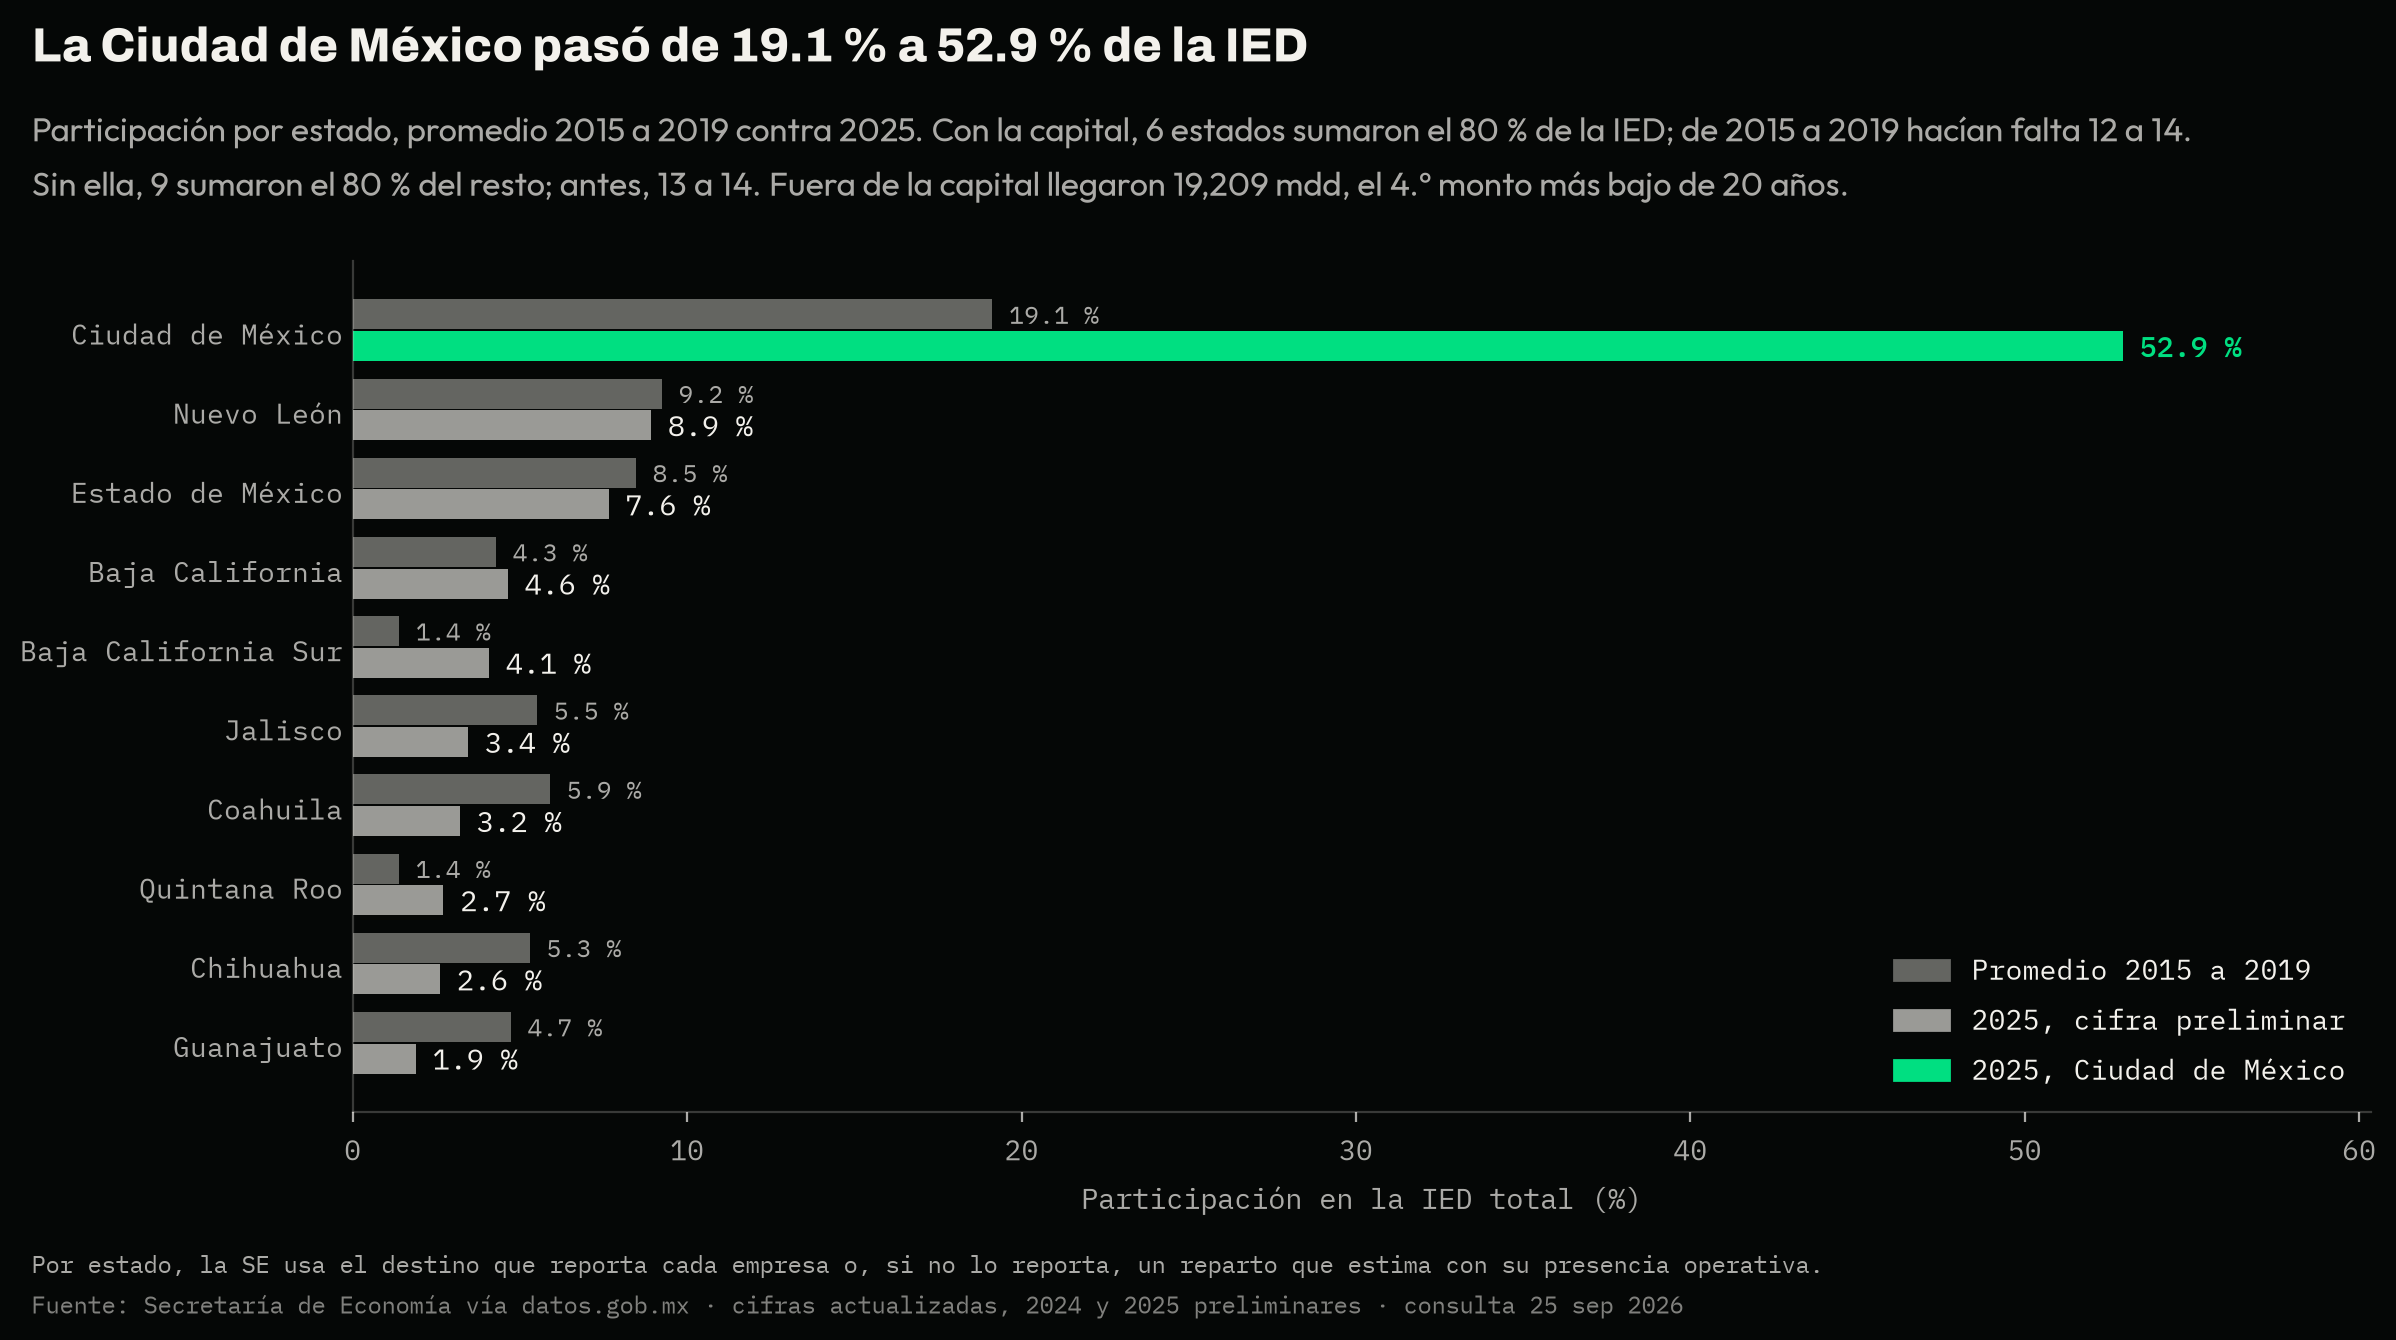

In [4]:
top = comparacion.head(10).iloc[::-1]
es_cdmx = top.index == "Ciudad de México"
fig, ax = plt.subplots()
y = range(len(top))
ax.barh([i + 0.2 for i in y], top["2015-2019"], height=0.38, color=PALETA["neutro"])
ax.barh([i - 0.2 for i in y], top[str(ULTIMO)], height=0.38,
        color=[PALETA["acento"] if c else PALETA["neutro_claro"] for c in es_cdmx])
for i, (b, u, c) in enumerate(zip(top["2015-2019"], top[str(ULTIMO)], es_cdmx)):
    ax.text(u + 0.5, i - 0.2, f"{u:.1f} %", va="center", fontsize=10.5, fontweight=500 if c else 400,
            color=PALETA["acento"] if c else PALETA["tinta"])
    ax.text(b + 0.5, i + 0.2, f"{b:.1f} %", va="center", fontsize=9, color=PALETA["tenue"])
ax.set_yticks(list(y), top.index)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, top[str(ULTIMO)].max() * 1.14)
ax.set_xlabel("Participación en la IED total (%)")
ax.legend(handles=[Patch(color=PALETA["neutro"], label="Promedio 2015 a 2019"),
                   Patch(color=PALETA["neutro_claro"], label=f"{ULTIMO}, cifra preliminar"),
                   Patch(color=PALETA["acento"], label=f"{ULTIMO}, Ciudad de México")], loc="lower right")
base_cdmx, ultimo_cdmx = comparacion.loc["Ciudad de México"]
arriba = encabezado(
    fig, f"La Ciudad de México pasó de {base_cdmx:.1f} % a {ultimo_cdmx:.1f} % de la IED",
    f"Participación por estado, promedio 2015 a 2019 contra {ULTIMO}. Con la capital, {n80[ULTIMO]} estados sumaron "
    f"el 80 % de la IED; de 2015 a 2019 hacían falta {rango(n80.loc[2015:2019])}.\nSin ella, {n80_sin[ULTIMO]} sumaron "
    f"el 80 % del resto; antes, {rango(n80_sin.loc[2015:2019])}. Fuera de la capital llegaron {fuera[ULTIMO]:,.0f} mdd, "
    f"el {lugar_fuera}.º monto más bajo de {len(fuera)} años.")
pie(fig, nota="Por estado, la SE usa el destino que reporta cada empresa o, si no lo reporta, "
              "un reparto que estima con su presencia operativa.")
plt.tight_layout(rect=(0, 0.065, 1, arriba))
plt.show()

## 1. Mucha reinversión, poco dinero nuevo

La IED tiene tres componentes. Las definiciones vienen del apéndice metodológico de la SE, sección 3.2 del [informe estadístico del cuarto trimestre de 2025](https://gaceta.diputados.gob.mx/PDF/66/2026/abr/InvExt-20260414.pdf):

- **Nuevas inversiones:** capital que ponen los inversionistas extranjeros al establecerse en México, al aumentar el capital de una empresa mexicana o al comprarle acciones a inversionistas mexicanos. Incluye adquisiciones: la compra de una empresa que ya existe cuenta aquí aunque no se construya nada.
- **Reinversión de utilidades:** ganancias de empresas con capital extranjero que no se reparten como dividendos.
- **Cuentas entre compañías:** deuda entre la empresa en México y otras de su mismo grupo en el extranjero.

In [5]:
tipo = leer("act_ti_tipodeinv")
anual_tipo = tipo.groupby(["anio", "tipo_inversion"])["flujo_mdd"].sum().unstack()
partes = anual_tipo.drop(columns="Total general")
pct = 100 * partes.div(anual_tipo["Total general"], axis=0)
reinv = pct["Reinversión de utilidades"]

print(f"Reinversión de utilidades, % de la IED: promedio 2006-2018 = {reinv.loc[2006:2018].mean():.1f} %, "
      f"2023 = {reinv[2023]:.1f} %, 2024 = {reinv[2024]:.1f} %, {ULTIMO} = {reinv[ULTIMO]:.1f} %")
mas_reinversion = partes["Reinversión de utilidades"].nlargest(3)
print("Los tres años con más reinversión: " + ", ".join(f"{a} ({v:,.0f} mdd)" for a, v in mas_reinversion.items()))
pd.concat([partes.round(0), reinv.round(1).rename("% reinversión")], axis=1).loc[2019:]

Reinversión de utilidades, % de la IED: promedio 2006-2018 = 36.6 %, 2023 = 73.0 %, 2024 = 75.7 %, 2025 = 67.7 %
Los tres años con más reinversión: 2024 (28,710 mdd), 2025 (27,649 mdd), 2023 (26,639 mdd)


,Cuentas entre compañías,Nuevas inversiones,Reinversión de utilidades,% reinversión
anio,,,,
2019,2869.0,13574.0,18179.0,52.5
2020,5319.0,6826.0,16135.0,57.1
2021,5455.0,15480.0,12913.0,38.2
2022,2028.0,18191.0,16202.0,44.5
2023,4552.0,5286.0,26639.0,73.0
2024,5115.0,4114.0,28710.0,75.7
2025,5844.0,7319.0,27649.0,67.7


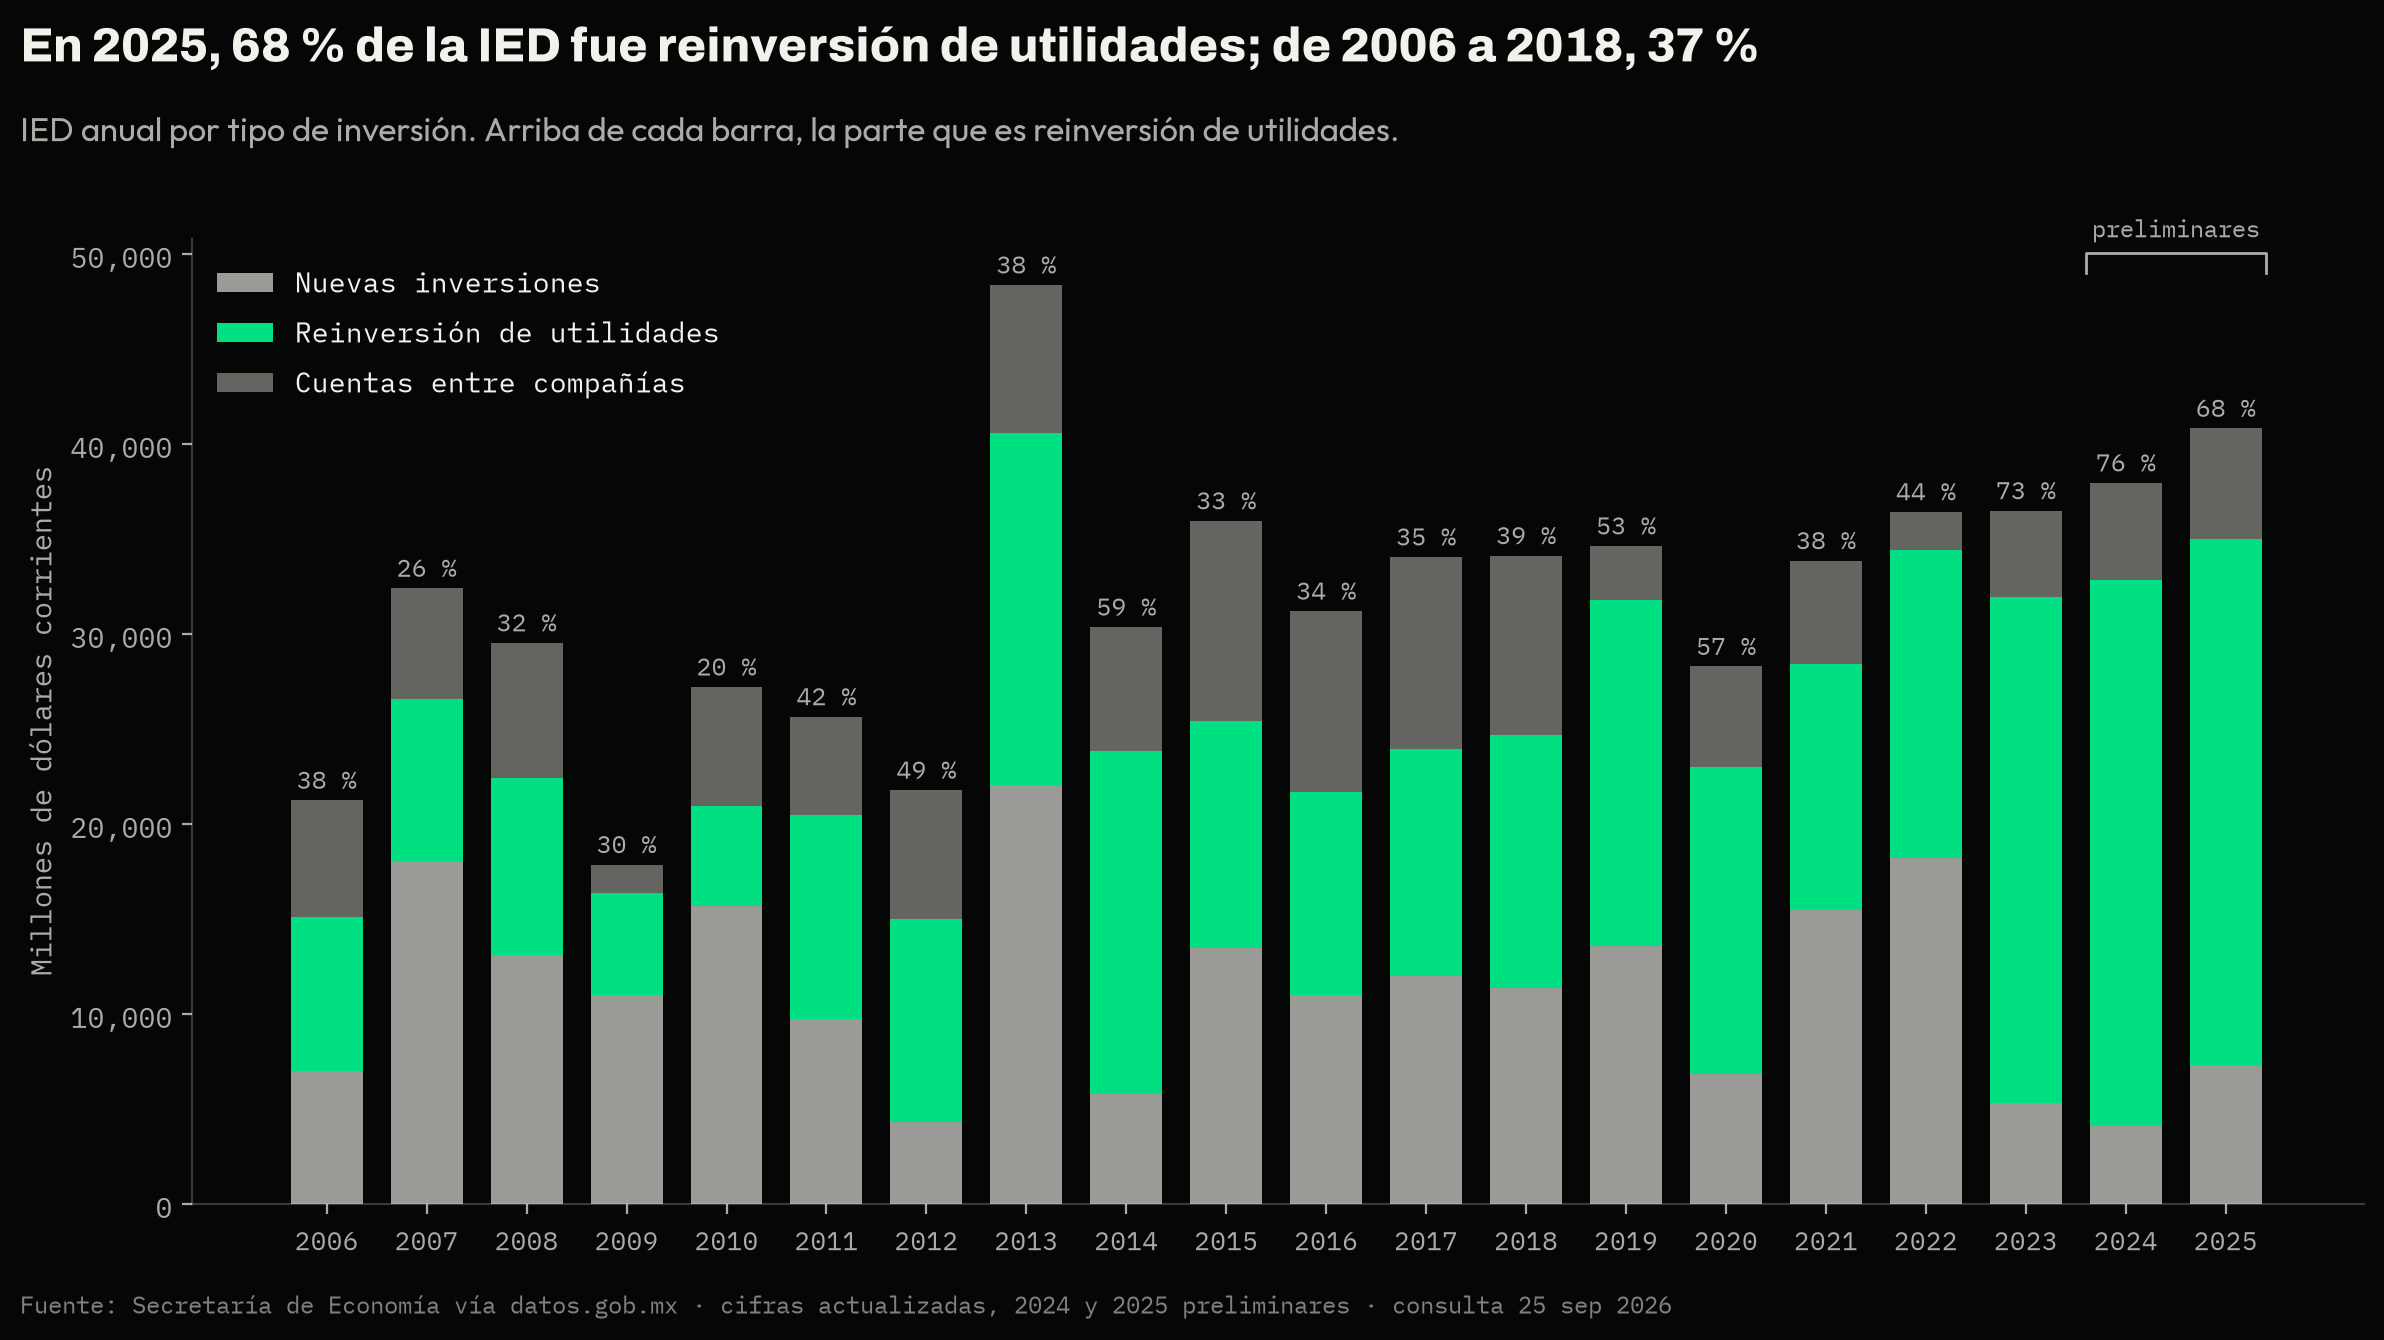

In [6]:
orden = ["Nuevas inversiones", "Reinversión de utilidades", "Cuentas entre compañías"]
col = {"Nuevas inversiones": PALETA["neutro_claro"], "Reinversión de utilidades": PALETA["acento"], "Cuentas entre compañías": PALETA["neutro"]}
fig, ax = plt.subplots()
abajo = pd.Series(0.0, index=partes.index)
for c in orden:
    ax.bar(partes.index, partes[c], bottom=abajo, color=col[c], label=c, width=0.72)
    abajo = abajo + partes[c].fillna(0)
for anio, valor in anual_tipo["Total general"].items():
    ax.text(anio, valor + 600, f"{reinv[anio]:.0f} %", ha="center", fontsize=9, color=PALETA["tenue"])
marcar_preliminares(ax)
ax.set_ylabel("Millones de dólares corrientes")
miles(ax.yaxis)
ax.set_xticks(list(partes.index))
ax.tick_params(axis="x", labelsize=9.5)
ax.legend(loc="upper left")
arriba = encabezado(fig, f"En {ULTIMO}, {reinv[ULTIMO]:.0f} % de la IED fue reinversión de utilidades; "
                         f"de 2006 a 2018, {reinv.loc[2006:2018].mean():.0f} %",
                    "IED anual por tipo de inversión. Arriba de cada barra, la parte que es reinversión de utilidades.")
pie(fig)
plt.tight_layout(rect=(0, 0.035, 1, arriba))
plt.show()

**Segundo en dólares corrientes, décimo en constantes.** En dólares corrientes, 2025 queda detrás de 2013. Para comparar poder de compra entre años, la serie se deflacta con el promedio anual del CPI-U de Estados Unidos y se expresa en dólares de 2025. El CPI-U mide precios al consumidor en Estados Unidos; sirve para poner montos en dólares de un mismo año, aunque no mide el costo de invertir en México.

In [7]:
cpi = leer("cpi_eeuu").set_index("anio")["cpi_promedio"]
FACTOR = cpi[ULTIMO] / cpi  # multiplica los dólares de cada año para expresarlos en dólares de ULTIMO
corrientes = anual_tipo["Total general"]
constantes = corrientes * FACTOR.loc[corrientes.index]
lugares = pd.DataFrame({
    "mdd corrientes": corrientes.round(0),
    f"mdd de {ULTIMO}": constantes.round(0),
    "lugar en corrientes": corrientes.rank(ascending=False).astype(int),
    "lugar en constantes": constantes.rank(ascending=False).astype(int),
})
maximo = int(corrientes.idxmax())
print(f"{ULTIMO}: {corrientes[ULTIMO]:,.0f} mdd, lugar {lugares.loc[ULTIMO, 'lugar en corrientes']} de {len(lugares)} "
      f"en dólares corrientes y {lugares.loc[ULTIMO, 'lugar en constantes']} en dólares de {ULTIMO}")
print(f"Año más alto en ambas medidas: {maximo}, {corrientes[maximo]:,.0f} mdd corrientes, "
      f"{constantes[maximo]:,.0f} mdd de {ULTIMO}")
lugares.sort_values(f"mdd de {ULTIMO}", ascending=False).head(10)

2025: 40,812 mdd, lugar 2 de 20 en dólares corrientes y 10 en dólares de 2025
Año más alto en ambas medidas: 2013, 48,357 mdd corrientes, 66,834 mdd de 2025


,mdd corrientes,mdd de 2025,lugar en corrientes,lugar en constantes
anio,,,,
2013,48357.0,66834.0,1,1
2007,32394.0,50301.0,11,2
2015,35945.0,48831.0,6,3
2017,34043.0,44715.0,9,4
2008,29521.0,44156.0,14,5
2018,34111.0,43737.0,8,6
2019,34622.0,43602.0,7,7
2016,31192.0,41844.0,12,8
2014,30352.0,41282.0,13,9


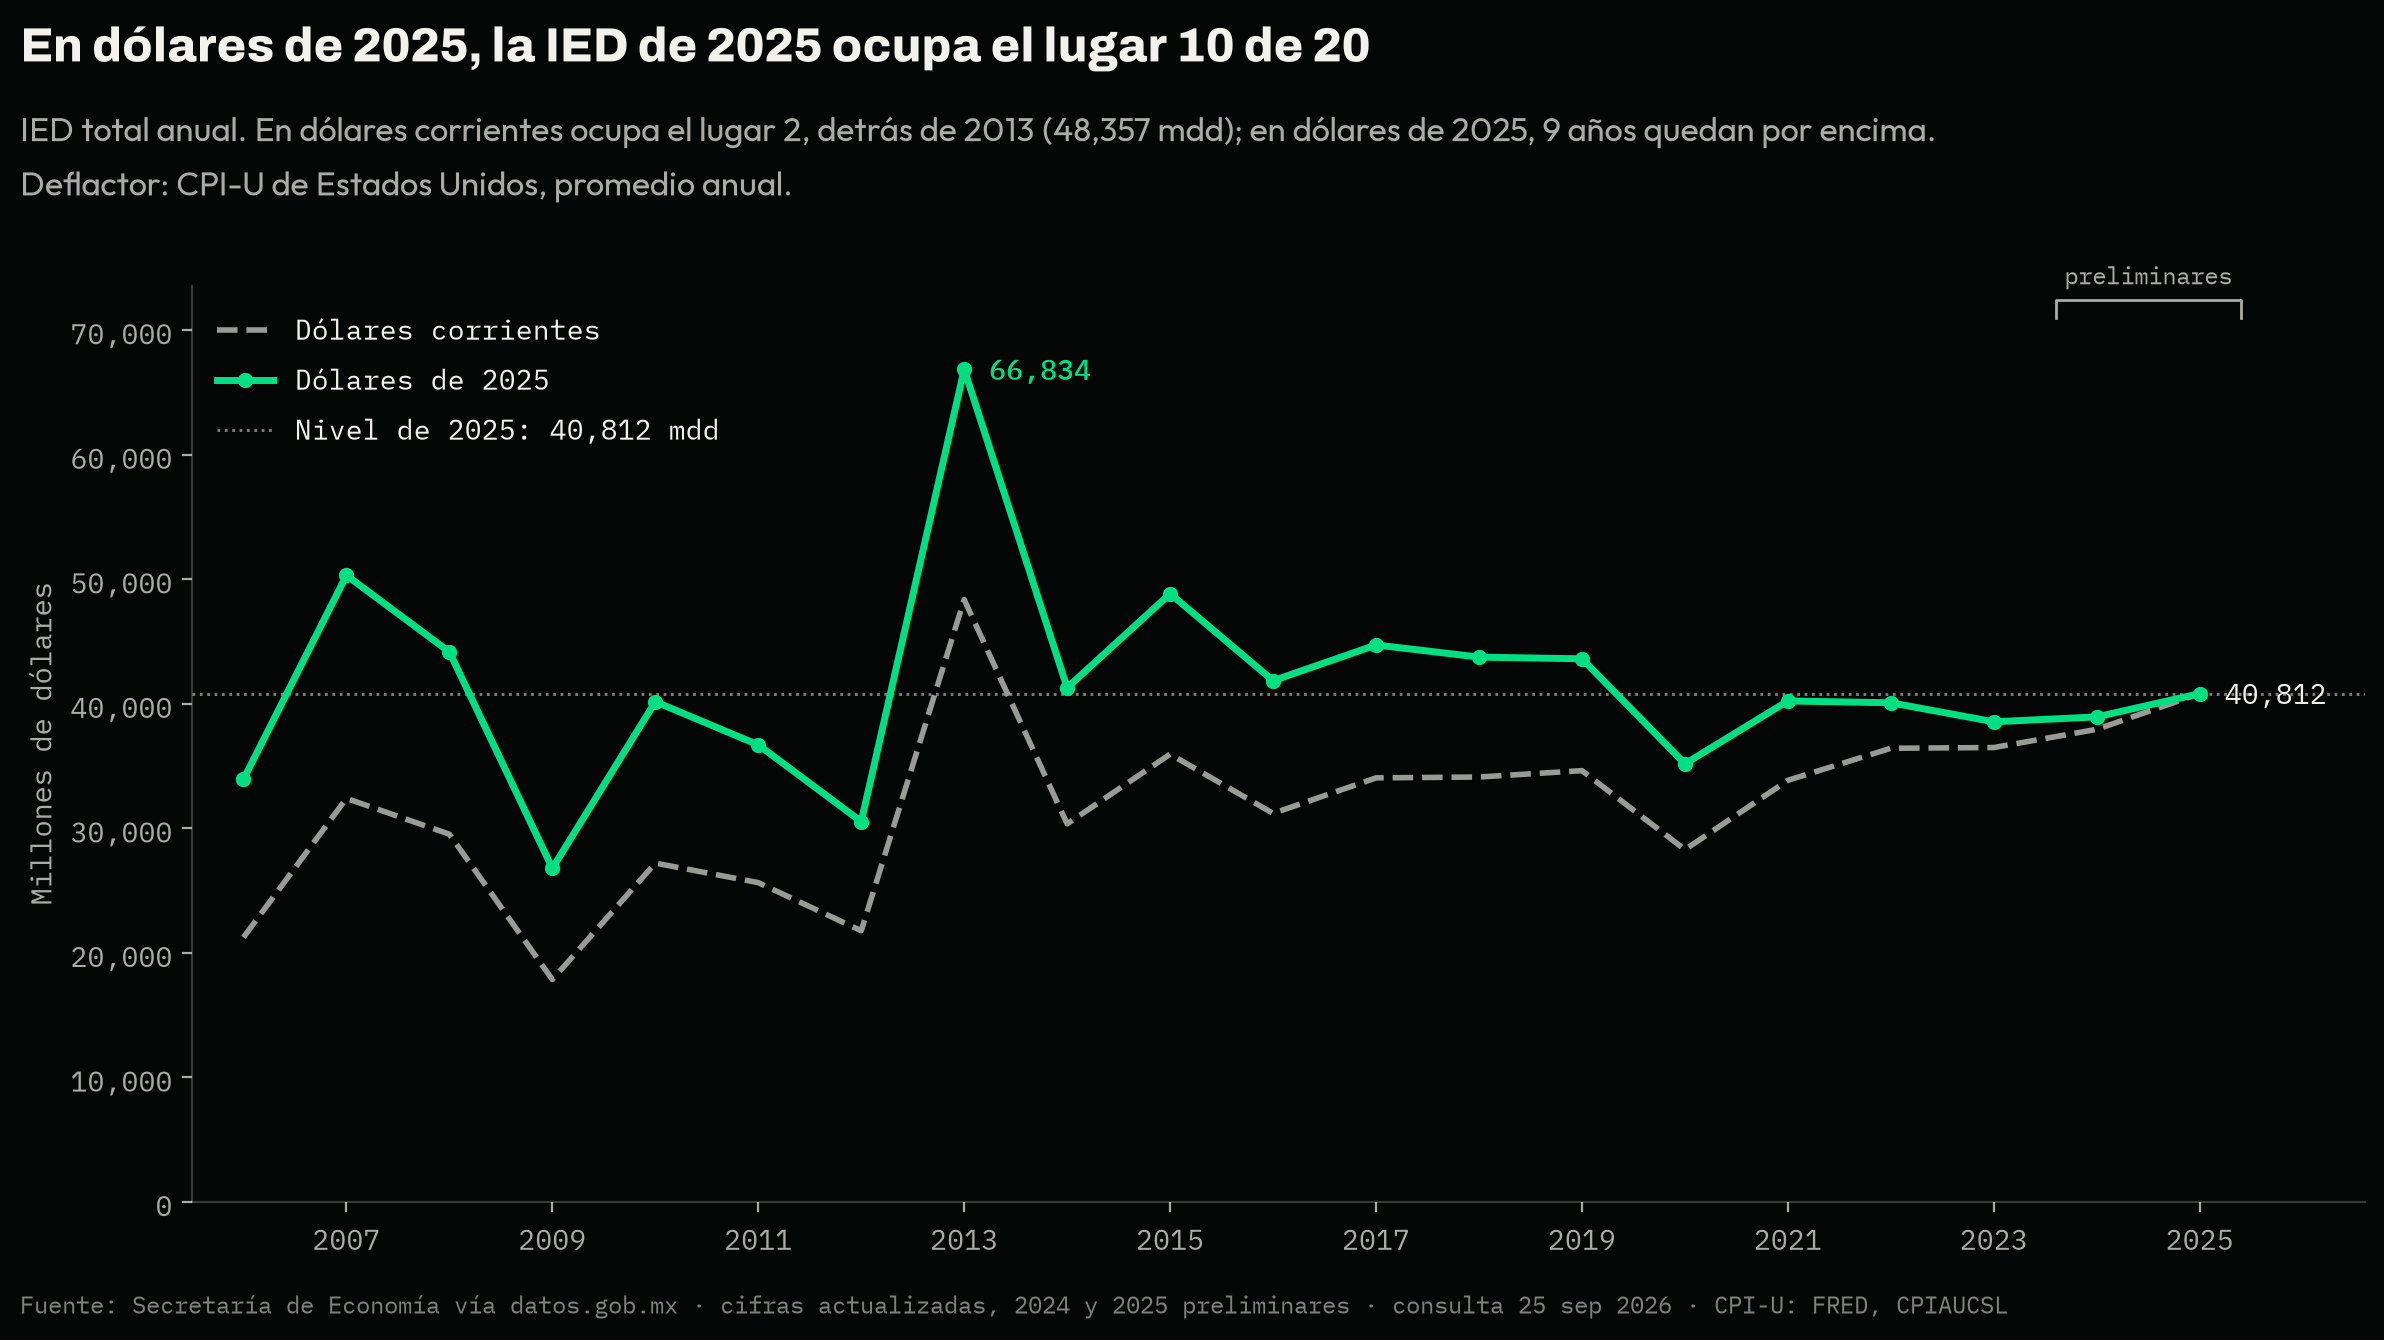

In [8]:
fig, ax = plt.subplots()
ax.plot(corrientes.index, corrientes.values, color=PALETA["neutro_claro"], lw=2, ls="--", label="Dólares corrientes")
ax.plot(constantes.index, constantes.values, color=PALETA["acento"], lw=2.5, marker="o", ms=4.5, label=f"Dólares de {ULTIMO}")
ax.axhline(corrientes[ULTIMO], color=PALETA["leve"], lw=1, ls=":", zorder=1,
           label=f"Nivel de {ULTIMO}: {corrientes[ULTIMO]:,.0f} mdd")
ax.annotate(f"{constantes[maximo]:,.0f}", (maximo, constantes[maximo]), xytext=(9, 0), textcoords="offset points",
            va="center", fontsize=10, color=PALETA["acento"], fontweight=500)
ax.annotate(f"{corrientes[ULTIMO]:,.0f}", (ULTIMO, corrientes[ULTIMO]), xytext=(9, 0), textcoords="offset points",
            va="center", fontsize=10, color=PALETA["tinta"])
marcar_preliminares(ax)
ax.set_xlim(2005.5, ULTIMO + 1.6)
ax.set_ylim(0, constantes.max() * 1.1)
ax.set_xticks(list(range(ULTIMO - 18, ULTIMO + 1, 2)))
ax.set_ylabel("Millones de dólares")
miles(ax.yaxis)
ax.legend(loc="upper left")
arriba = encabezado(
    fig, f"En dólares de {ULTIMO}, la IED de {ULTIMO} ocupa el lugar {lugares.loc[ULTIMO, 'lugar en constantes']} de {len(lugares)}",
    f"IED total anual. En dólares corrientes ocupa el lugar {lugares.loc[ULTIMO, 'lugar en corrientes']}, detrás de {maximo} "
    f"({corrientes[maximo]:,.0f} mdd); en dólares de {ULTIMO}, {int((constantes > corrientes[ULTIMO]).sum())} años quedan "
    f"por encima.\nDeflactor: CPI-U de Estados Unidos, promedio anual.")
pie(fig, extra=" · CPI-U: FRED, CPIAUCSL")
plt.tight_layout(rect=(0, 0.035, 1, arriba))
plt.show()

El pico de 2013 tiene una causa concentrada. El subsector 312, industria de las bebidas y del tabaco, sumó un tercio de la IED de ese año, y las nuevas inversiones de 2013 son las más altas de la serie. El año y el monto cuadran con la compra de Grupo Modelo por AB InBev, que se cerró en 2013, pero el dataset no identifica empresas: la atribución a esa operación es una inferencia.

In [9]:
sector = leer("act_ti_sector")
subsectores = sector[(sector.trimestre == 4) & (sector.scian_nivel == "subsector")]
pico = subsectores[subsectores.anio == maximo].nlargest(3, "ied_acumulado_mdd")[["sector_subsector_rama", "ied_acumulado_mdd"]]
mayor = pico.iloc[0]
print(f"{maximo}: {mayor.sector_subsector_rama} sumó {mayor.ied_acumulado_mdd:,.0f} mdd, "
      f"{100 * mayor.ied_acumulado_mdd / corrientes[maximo]:.1f} % de la IED del año; "
      f"sin ese subsector, {maximo} suma {corrientes[maximo] - mayor.ied_acumulado_mdd:,.0f} mdd")
nuevas = partes["Nuevas inversiones"]
print(f"Nuevas inversiones de {maximo}: {nuevas[maximo]:,.0f} mdd; el año más alto de la serie es {int(nuevas.idxmax())}")
pico

2013: 312 Industria de las bebidas y del tabaco sumó 16,357 mdd, 33.8 % de la IED del año; sin ese subsector, 2013 suma 32,000 mdd
Nuevas inversiones de 2013: 22,041 mdd; el año más alto de la serie es 2013


,sector_subsector_rama,ied_acumulado_mdd
4991,312 Industria de las bebidas y del tabaco,16356.692070
2111,212 Minería de minerales metálicos y no metáli...,5520.896872
11551,336 Fabricación de equipo de transporte,4580.387425


**Qué aguanta la revisión.** La SE publica todas sus cifras como preliminares y las corrige en cada informe trimestral; las correcciones más grandes caen en los trimestres recientes (sección 3.8 del mismo apéndice). La tabla compara la primera cifra publicada de cada año, que trae la tabla de originales, con la actual, y cuenta cuántos informes han corregido ya el cuarto trimestre de cada año.

In [10]:
orig = leer("orig_ti_tipodeinv")
orig_anual = orig[orig.trimestre == 4].pivot(index="anio", columns="tipo_inversion", values="ied_acumulado_mdd")
anios = orig_anual.index
ultimo_anio, ultimo_trim = (int(x) for x in MANIFIESTO["ultimo_trimestre"].split("-T"))
revisiones = pd.DataFrame({
    "total original": orig_anual["Total general"],
    "total actual": corrientes.loc[anios],
    "nuevas original": orig_anual["Nuevas inversiones"],
    "nuevas actual": nuevas.loc[anios],
    "reinversión % original": 100 * orig_anual["Reinversión de utilidades"] / orig_anual["Total general"],
    "reinversión % actual": reinv.loc[anios],
})
revisiones["total, cambio %"] = 100 * (revisiones["total actual"] / revisiones["total original"] - 1)
revisiones["nuevas, cambio %"] = 100 * (revisiones["nuevas actual"] / revisiones["nuevas original"] - 1)
revisiones["informes que lo corrigieron"] = (ultimo_anio * 4 + ultimo_trim) - (anios * 4 + 4)

cambio_nuevas = revisiones["nuevas, cambio %"]
print(f"Total anual 2018-{ULTIMO}: entre {revisiones['total, cambio %'].min():+.1f} % y {revisiones['total, cambio %'].max():+.1f} % "
      f"desde la primera cifra")
print(f"Nuevas inversiones 2019-2023: entre {cambio_nuevas.loc[2019:2023].min():+.1f} % y {cambio_nuevas.loc[2019:2023].max():+.1f} %; "
      f"2024: {cambio_nuevas[2024]:+.1f} % (de {revisiones.loc[2024, 'nuevas original']:,.1f} a {revisiones.loc[2024, 'nuevas actual']:,.1f} mdd)")
print(f"Reinversión, % de la IED con la primera cifra: 2024 = {revisiones.loc[2024, 'reinversión % original']:.1f} %, "
      f"{ULTIMO} = {revisiones.loc[ULTIMO, 'reinversión % original']:.1f} %")

bajas = nuevas.sort_values()
margen = 100 * (bajas.iloc[1] / bajas.iloc[0] - 1)
print(f"Nuevas inversiones más bajas en dólares corrientes: {bajas.index[0]} ({bajas.iloc[0]:,.0f} mdd) y {bajas.index[1]} "
      f"({bajas.iloc[1]:,.0f}); a {bajas.index[0]} le basta una revisión de {margen:+.1f} % para empatar")
bajas_c = (nuevas * FACTOR.loc[nuevas.index]).sort_values()
margen_c = 100 * (bajas_c.iloc[1] / bajas_c.iloc[0] - 1)
print(f"En dólares de {ULTIMO}: {bajas_c.index[0]} ({bajas_c.iloc[0]:,.0f}) y {bajas_c.index[1]} ({bajas_c.iloc[1]:,.0f}); "
      f"haría falta una revisión de {margen_c:+.1f} %")
revisiones.round(1)

Total anual 2018-2025: entre -2.7 % y +7.9 % desde la primera cifra
Nuevas inversiones 2019-2023: entre +5.8 % y +12.0 %; 2024: +29.8 % (de 3,168.5 a 4,114.2 mdd)
Reinversión, % de la IED con la primera cifra: 2024 = 77.9 %, 2025 = 67.7 %
Nuevas inversiones más bajas en dólares corrientes: 2024 (4,114 mdd) y 2012 (4,317); a 2024 le basta una revisión de +4.9 % para empatar
En dólares de 2025: 2024 (4,223) y 2023 (5,586); haría falta una revisión de +32.3 %


,total original,total actual,nuevas original,nuevas actual,reinversión % original,reinversión % actual,"total, cambio %","nuevas, cambio %",informes que lo corrigieron
anio,,,,,,,,,
2018,31604.3,34111.0,11468.3,11333.8,38.8,39.0,7.9,-1.2,29
2019,32921.2,34622.0,12826.8,13574.0,53.1,52.5,5.2,5.8,25
2020,29079.4,28280.2,6408.5,6825.6,55.4,57.1,-2.7,6.5,21
2021,31621.2,33847.7,13825.3,15479.6,38.6,38.2,7.0,12.0,17
2022,35291.6,36420.5,16993.1,18190.7,45.4,44.5,3.2,7.0,13
2023,36058.0,36477.6,4817.4,5286.1,73.9,73.0,1.2,9.7,9
2024,36872.4,37939.3,3168.5,4114.2,77.9,75.7,2.9,29.8,5
2025,40870.8,40812.1,7377.4,7318.7,67.7,67.7,-0.1,-0.8,1


- **La reinversión alta aguanta.** Con la primera cifra publicada, la reinversión es 77.9 % de la IED de 2024 y 67.7 % de la de 2025; con la actual, 75.7 % y 67.7 %. El promedio de 2006 a 2018 es 36.6 %.
- **El mínimo de nuevas inversiones de 2024 es frágil en dólares corrientes.** Los 4,114 mdd de 2024 quedan 203 mdd debajo de los 4,317 de 2012: una revisión de +4.9 % los empata. Entre 2019 y 2023 la SE subió las nuevas inversiones entre 5.8 % y 12.0 % desde su primera cifra, y la de 2024 ya subió 29.8 %. Una revisión como esas basta para que 2012 vuelva a ser el año más bajo.
- **En dólares de 2025 el mínimo es más firme:** 2024 tendría que subir 32.3 % para alcanzar a 2023, el siguiente año más bajo.
- Por eso 2024 y 2025 van marcados como preliminares en las gráficas: el cuarto trimestre de 2025 lleva un solo informe de corrección y el de 2024, cinco.

## 2. La capital absorbe y el resto del país recibe menos

Desde 2015 la SE asigna la IED de cada empresa al estado donde opera: usa el destino que reporta la propia empresa o, si no lo tiene, un reparto que la SE estima con su estructura corporativa y su presencia operativa (apéndice metodológico, sección 3.4, y [síntesis metodológica de la SE](https://www.gob.mx/cms/uploads/attachment/file/274849/Sintesis_metodologica_IED.pdf), sección 4). Las tablas no dicen qué parte de cada estado viene de cada criterio. La participación de un estado describe esa asignación; con estos datos no se puede ubicar cada dólar en una planta.

Tres medidas separan a la capital del resto: su parte de cada tipo de inversión, cuánta IED se asignó fuera de ella y cuántos estados suman el 80 % con ella y sin ella.

In [11]:
ef = leer("act_ef_tipodeinv")
ef4 = ef[(ef.trimestre == 4) & (ef.entidad_federativa != "Total general")]
cdmx_tipo = pd.DataFrame({
    t: 100 * ef4[(ef4.tipo_inversion == t) & (ef4.entidad_federativa == "Ciudad de México")].set_index("anio")["ied_acumulado_mdd"] / anual_tipo[t]
    for t in ["Total general", "Nuevas inversiones", "Reinversión de utilidades", "Cuentas entre compañías"]
})
cdmx = cdmx_tipo["Total general"]
fuera_c = fuera * FACTOR.loc[fuera.index]
lugar_fuera_c = int(fuera_c.rank()[ULTIMO])
debajo_c = [int(a) for a in fuera_c[fuera_c < fuera_c[ULTIMO]].index]
print(f"CDMX, % de la IED: promedio 2006-2018 = {cdmx.loc[2006:2018].mean():.1f} %, 2024 = {cdmx[2024]:.1f} %, {ULTIMO} = {cdmx[ULTIMO]:.1f} %")
for t in ["Reinversión de utilidades", "Nuevas inversiones", "Cuentas entre compañías"]:
    print(f"CDMX, % de {t.lower()}: promedio 2006-2018 = {cdmx_tipo[t].loc[2006:2018].mean():.1f} %, {ULTIMO} = {cdmx_tipo[t][ULTIMO]:.1f} %")
print(f"IED fuera de la CDMX en {ULTIMO}: {fuera[ULTIMO]:,.0f} mdd, el {lugar_fuera}.º monto más bajo de {len(fuera)} años en dólares corrientes "
      f"y el {lugar_fuera_c}.º en dólares de {ULTIMO} (más bajo: {', '.join(map(str, debajo_c))})")
print(f"Estados para el 80 %: promedio 2006-2018 = {n80.loc[2006:2018].mean():.1f}, 2019 = {n80[2019]}, 2024 = {n80[2024]}, {ULTIMO} = {n80[ULTIMO]}")
print(f"Sin la CDMX, estados para el 80 % del resto: 2019 = {n80_sin[2019]}, 2024 = {n80_sin[2024]}, {ULTIMO} = {n80_sin[ULTIMO]}")
pd.DataFrame({
    "CDMX % IED": cdmx.round(1),
    "CDMX % reinversión": cdmx_tipo["Reinversión de utilidades"].round(1),
    "fuera de la CDMX, mdd": fuera.round(0),
    f"fuera, mdd de {ULTIMO}": fuera_c.round(0),
    "estados para 80 %": n80,
    "sin la CDMX": n80_sin,
})

CDMX, % de la IED: promedio 2006-2018 = 19.7 %, 2024 = 40.9 %, 2025 = 52.9 %
CDMX, % de reinversión de utilidades: promedio 2006-2018 = 26.3 %, 2025 = 57.4 %
CDMX, % de nuevas inversiones: promedio 2006-2018 = 18.9 %, 2025 = 38.6 %
CDMX, % de cuentas entre compañías: promedio 2006-2018 = 11.7 %, 2025 = 49.9 %
IED fuera de la CDMX en 2025: 19,209 mdd, el 4.º monto más bajo de 20 años en dólares corrientes y el 2.º en dólares de 2025 (más bajo: 2009)
Estados para el 80 %: promedio 2006-2018 = 12.8, 2019 = 13, 2024 = 10, 2025 = 6
Sin la CDMX, estados para el 80 % del resto: 2019 = 14, 2024 = 13, 2025 = 9


,CDMX % IED,CDMX % reinversión,"fuera de la CDMX, mdd","fuera, mdd de 2025",estados para 80 %,sin la CDMX
anio,,,,,,
2006,26.7,39.7,15566.0,24864.0,11,12
2007,21.4,30.6,25462.0,39538.0,13,14
2008,26.2,34.3,21791.0,32593.0,12,14
2009,29.4,42.3,12597.0,18902.0,12,13
2010,14.9,30.5,23134.0,34155.0,12,12
2011,29.3,28.8,18125.0,25945.0,12,14
2012,6.1,18.2,20432.0,28653.0,15,15
2013,12.1,15.5,42521.0,58769.0,15,15
2014,20.2,24.0,24225.0,32949.0,13,14


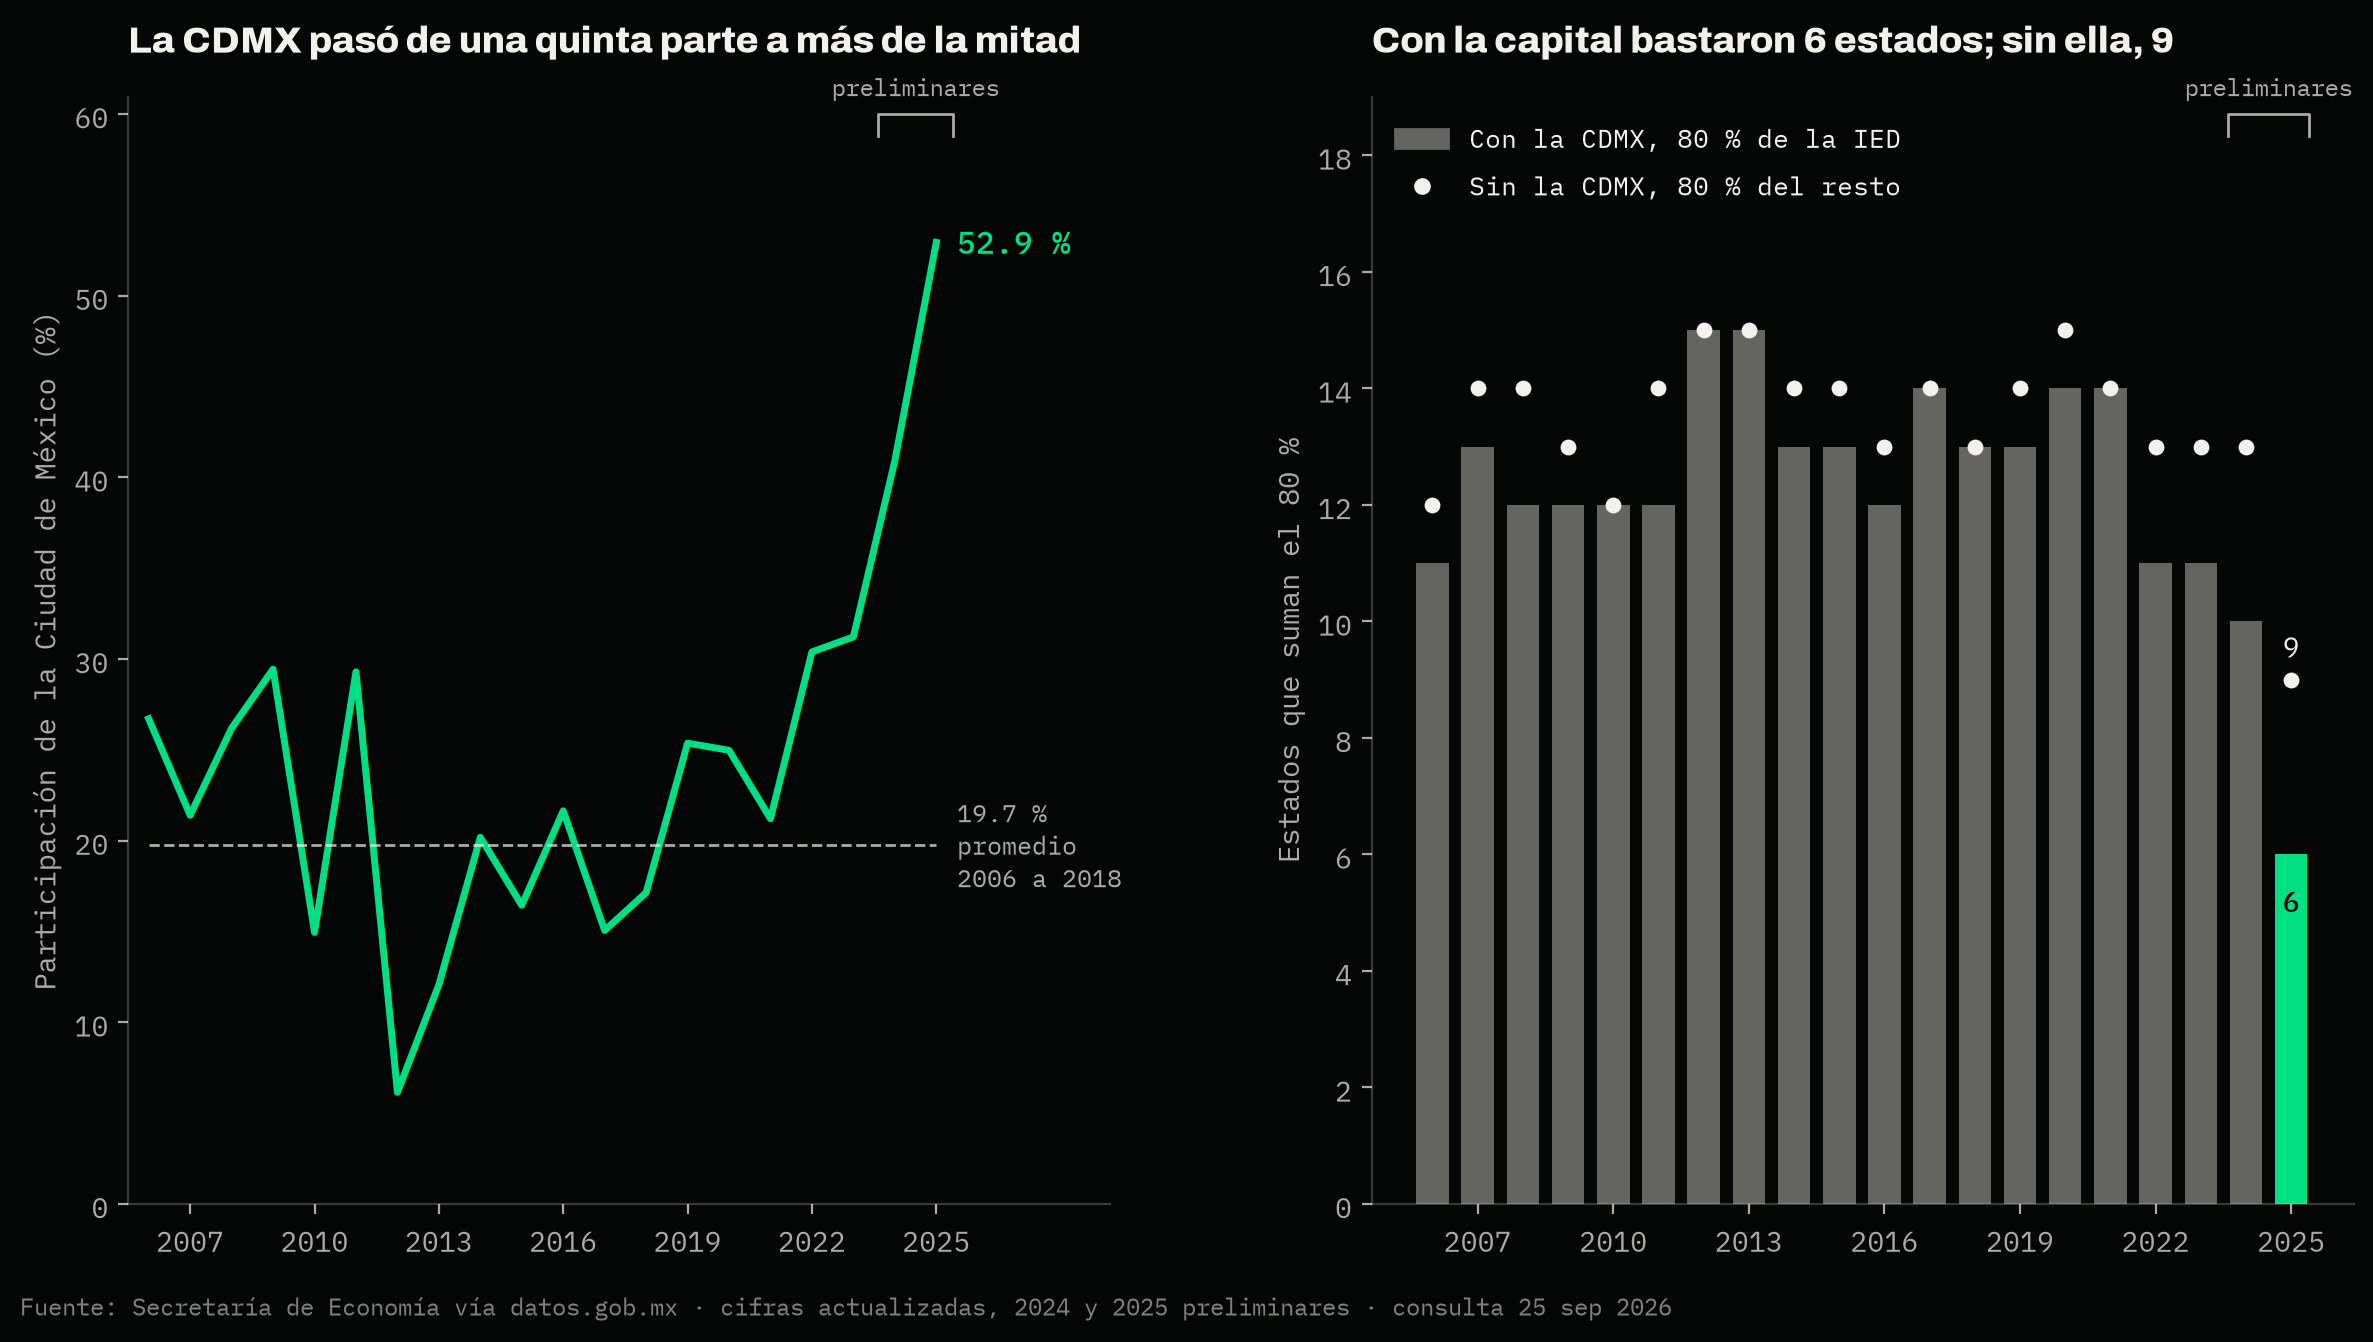

In [12]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 6.75))
promedio = cdmx.loc[2006:2018].mean()
a1.plot(cdmx.index, cdmx.values, color=PALETA["acento"], linewidth=2.5)
a1.hlines(promedio, 2006, ULTIMO, color=PALETA["tenue"], linestyle="--", linewidth=1)
a1.text(ULTIMO + 0.5, promedio, f"{promedio:.1f} %\npromedio\n2006 a 2018", va="center", fontsize=9, color=PALETA["tenue"])
a1.text(ULTIMO + 0.5, cdmx[ULTIMO], f"{cdmx[ULTIMO]:.1f} %", va="center", fontsize=11, color=PALETA["acento"], fontweight=500)
a1.set_xlim(2005.5, ULTIMO + 4.2)
a1.set_ylim(0, max(60, cdmx.max() + 8))
a1.set_ylabel("Participación de la Ciudad de México (%)")
titulo_panel(a1, "La CDMX pasó de una quinta parte a más de la mitad")
a2.bar(n80.index, n80.values, color=[PALETA["acento"] if a == ULTIMO else PALETA["neutro"] for a in n80.index], width=0.72)
a2.scatter(n80_sin.index, n80_sin.values, color=PALETA["tinta"], s=22, zorder=3)
a2.text(ULTIMO, n80[ULTIMO] - 0.5, str(n80[ULTIMO]), ha="center", va="top", fontsize=10, color=PALETA["papel"], fontweight=500)
a2.annotate(str(n80_sin[ULTIMO]), (ULTIMO, n80_sin[ULTIMO]), xytext=(0, 8), textcoords="offset points",
            ha="center", fontsize=10, color=PALETA["tinta"])
a2.set_ylabel("Estados que suman el 80 %")
a2.set_ylim(0, max(n80.max(), n80_sin.max()) + 4)
a2.yaxis.set_major_locator(MaxNLocator(integer=True))
a2.legend(handles=[Patch(color=PALETA["neutro"], label="Con la CDMX, 80 % de la IED"),
                   Line2D([], [], color=PALETA["tinta"], marker="o", ls="", ms=5, label="Sin la CDMX, 80 % del resto")],
          loc="upper left", fontsize=9.5)
titulo_panel(a2, f"Con la capital bastaron {n80[ULTIMO]} estados; sin ella, {n80_sin[ULTIMO]}")
for a in (a1, a2):
    a.set_xticks(list(range(ULTIMO - 18, ULTIMO + 1, 3)))
    marcar_preliminares(a)
pie(fig)
plt.tight_layout(rect=(0, 0.035, 1, 1), w_pad=4)
plt.show()

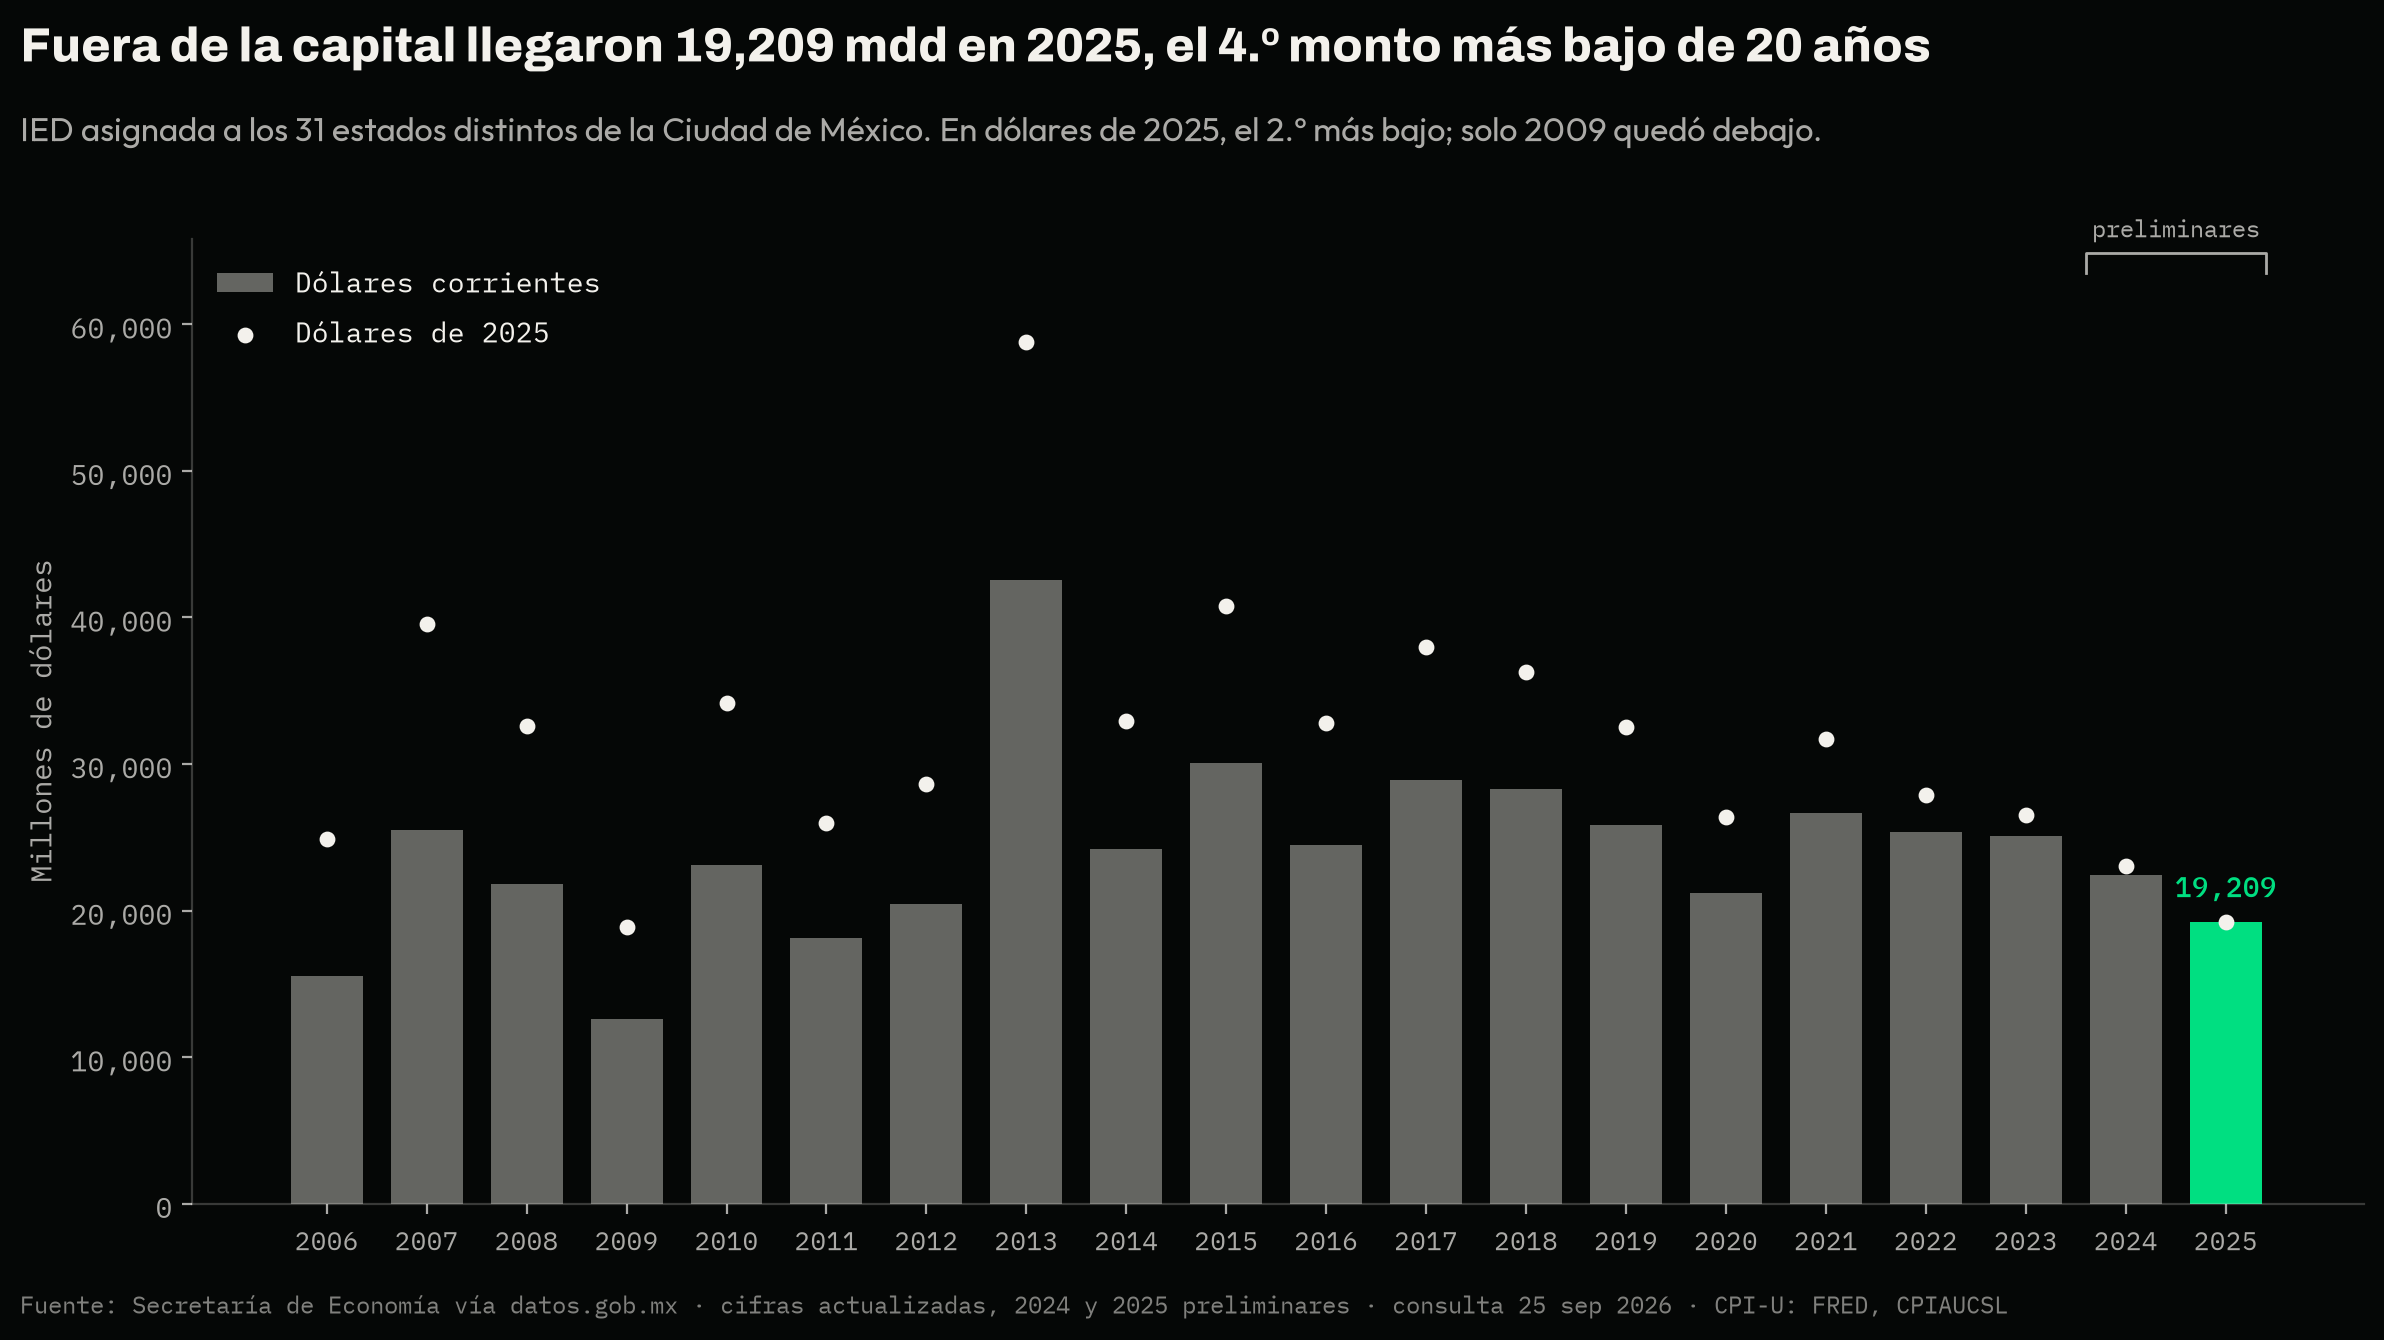

In [13]:
fig, ax = plt.subplots()
barras = ax.bar(fuera.index, fuera.values, width=0.72, color=[PALETA["acento"] if a == ULTIMO else PALETA["neutro"] for a in fuera.index])
puntos = ax.scatter(fuera_c.index, fuera_c.values, color=PALETA["tinta"], s=22, zorder=3)
ax.annotate(f"{fuera[ULTIMO]:,.0f}", (ULTIMO, fuera[ULTIMO]), xytext=(0, 9), textcoords="offset points",
            ha="center", fontsize=10, color=PALETA["acento"], fontweight=500)
marcar_preliminares(ax)
ax.set_xticks(list(fuera.index))
ax.tick_params(axis="x", labelsize=9.5)
ax.set_ylabel("Millones de dólares")
miles(ax.yaxis)
ax.set_ylim(0, fuera_c.max() * 1.12)
ax.legend([barras, puntos], ["Dólares corrientes", f"Dólares de {ULTIMO}"], loc="upper left")
arriba = encabezado(
    fig, f"Fuera de la capital llegaron {fuera[ULTIMO]:,.0f} mdd en {ULTIMO}, el {lugar_fuera}.º monto más bajo de {len(fuera)} años",
    f"IED asignada a los 31 estados distintos de la Ciudad de México. En dólares de {ULTIMO}, "
    f"el {lugar_fuera_c}.º más bajo; solo {', '.join(map(str, debajo_c))} quedó debajo.")
pie(fig, extra=" · CPI-U: FRED, CPIAUCSL")
plt.tight_layout(rect=(0, 0.035, 1, arriba))
plt.show()

En 2025 la capital recibió 52.9 % de la IED y 57.4 % de toda la reinversión de utilidades del país, contra 26.3 % en promedio de 2006 a 2018. Fuera de ella llegaron 19,209 mdd, el cuarto monto más bajo de veinte años en dólares corrientes y el segundo en dólares de 2025. El conteo de "6 estados para el 80 %" junta dos cosas: el peso de la capital y una concentración que también ocurrió en el resto, donde el 80 % lo sumaron 9 estados, contra 13 o 14 en cada año de 2015 a 2019.

## 3. De dónde viene: Estados Unidos manda, China casi no aparece como origen

La SE clasifica el país de origen "en función del origen de los recursos" (apéndice metodológico, sección 3.4). Su [síntesis metodológica](https://www.gob.mx/cms/uploads/attachment/file/274849/Sintesis_metodologica_IED.pdf) precisa que eso identifica al país donde reside el inversionista directo, que no siempre es el de quien controla la inversión en última instancia. Si una empresa invierte en México a través de una filial en un tercer país, el dinero cuenta para ese tercer país; estas tablas no permiten medir cuánto pasa eso. Las celdas confidenciales quedan fuera de la suma de países pero dentro del total.

In [14]:
origen = leer("act_ti_origen")
anual_pais = origen[origen.trimestre == 4].pivot(index="pais_origen", columns="anio", values="ied_acumulado_mdd")
total_pais = anual_pais.loc["Total general"]
share = 100 * anual_pais.drop(index="Total general") / total_pais
eeuu = share.loc["Estados Unidos de América"]
china = share.loc["China, República Popular de"]
print(f"Estados Unidos: {ULTIMO} = {eeuu[ULTIMO]:.1f} %, mínimo {eeuu.min():.1f} % ({eeuu.idxmin()}), máximo {eeuu.max():.1f} % ({eeuu.idxmax()})")
print(f"China: máximo {china.max():.1f} % en {china.idxmax()}, {ULTIMO} = {china[ULTIMO]:.1f} %")
top5 = share[ULTIMO].dropna().sort_values(ascending=False).head(5)
top5.round(1)

Estados Unidos: 2025 = 39.1 %, mínimo 31.9 % (2020), máximo 63.5 % (2006)
China: máximo 2.4 % en 2024, 2025 = 1.4 %


pais_origen
Estados Unidos de América    39.1
España                        8.6
Canadá                        8.5
Japón                         5.7
Suiza                         4.9
Name: 2025, dtype: float64

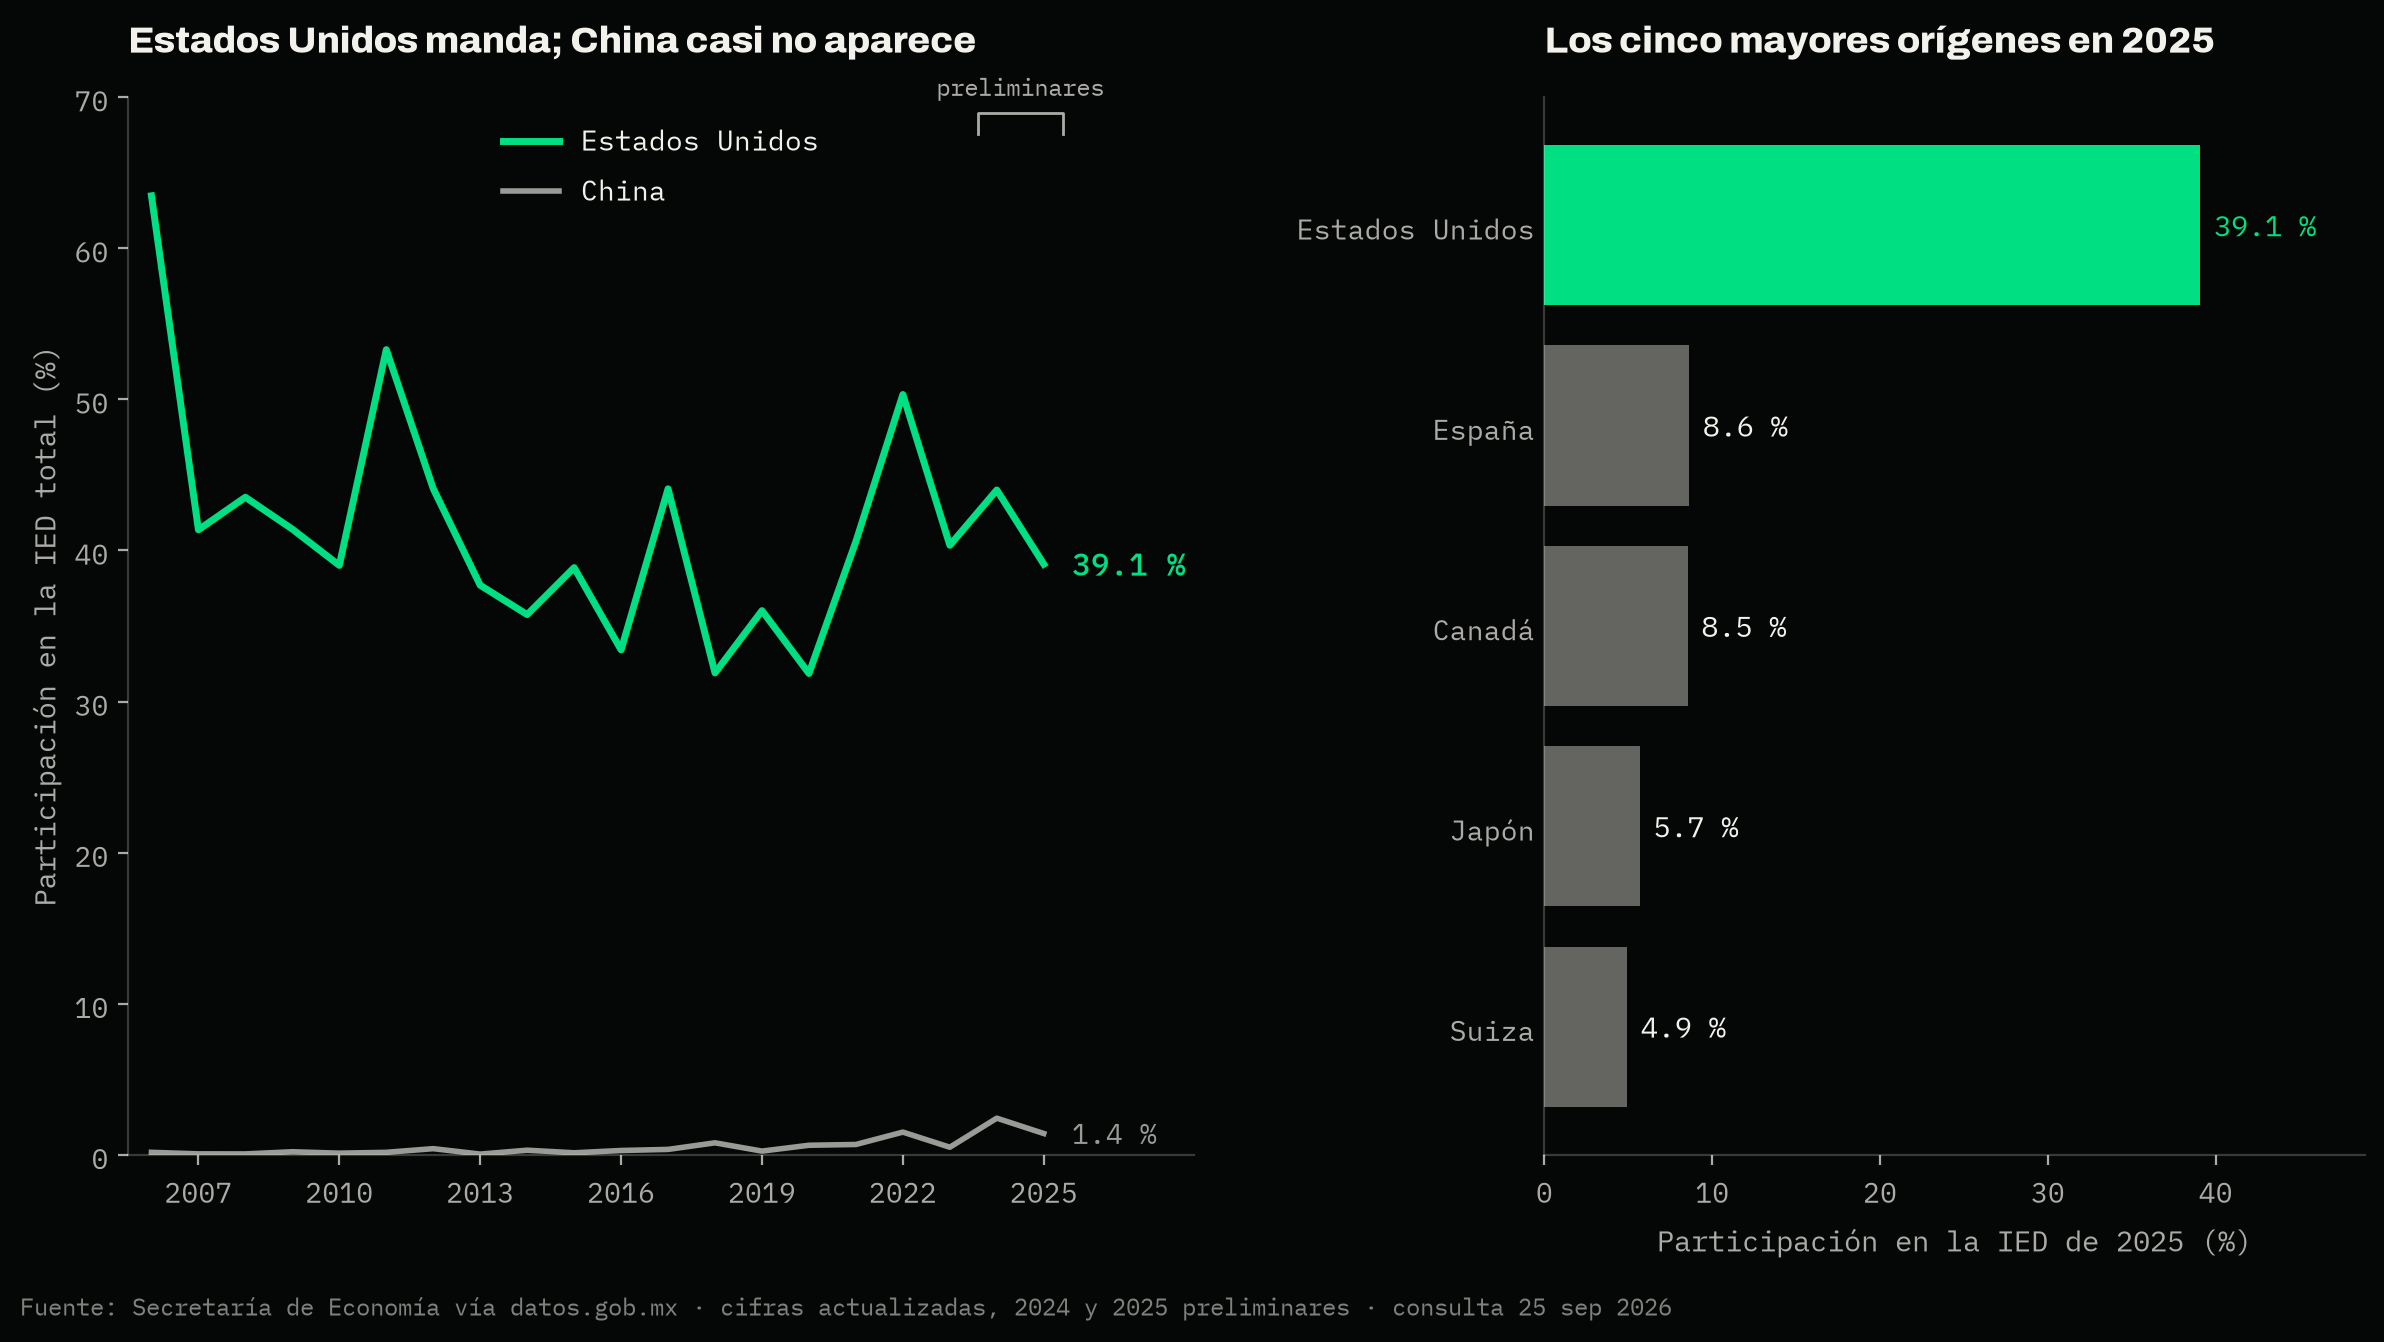

In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 6.75), gridspec_kw={"width_ratios": [1.3, 1]})
a1.plot(eeuu.index, eeuu.values, color=PALETA["acento"], linewidth=2.5, label="Estados Unidos")
a1.plot(china.index, china.values, color=PALETA["neutro_claro"], linewidth=2, label="China")
a1.text(ULTIMO + 0.6, eeuu[ULTIMO], f"{eeuu[ULTIMO]:.1f} %", va="center", fontsize=11, color=PALETA["acento"], fontweight=500)
a1.text(ULTIMO + 0.6, china[ULTIMO], f"{china[ULTIMO]:.1f} %", va="center", fontsize=10, color=PALETA["neutro_claro"])
marcar_preliminares(a1)
a1.set_ylim(0, 70)
a1.set_xlim(2005.5, ULTIMO + 3.2)
a1.set_xticks(list(range(ULTIMO - 18, ULTIMO + 1, 3)))
a1.set_ylabel("Participación en la IED total (%)")
a1.legend(loc="upper center")
titulo_panel(a1, "Estados Unidos manda; China casi no aparece")
t5 = top5.iloc[::-1]
a2.barh(t5.index.str.replace("Estados Unidos de América", "Estados Unidos"), t5.values,
        color=[PALETA["acento"] if "Estados Unidos" in p else PALETA["neutro"] for p in t5.index])
for i, (p, v) in enumerate(t5.items()):
    a2.text(v + 0.8, i, f"{v:.1f} %", va="center", fontsize=10.5,
            color=PALETA["acento"] if "Estados Unidos" in p else PALETA["tinta"])
a2.set_xlim(0, t5.max() * 1.25)
a2.tick_params(axis="y", length=0)
a2.set_xlabel(f"Participación en la IED de {ULTIMO} (%)")
titulo_panel(a2, f"Los cinco mayores orígenes en {ULTIMO}")
pie(fig)
plt.tight_layout(rect=(0, 0.035, 1, 1), w_pad=4)
plt.show()

## 4. A dónde va la inversión nueva

Si se aparta la reinversión y se mira solo la inversión nueva, que incluye compras de empresas ya existentes, la capital pesa menos que en el total pero sigue en primer lugar: 31.5 % de 2021 a 2025. La frontera norte (Baja California, Sonora, Chihuahua, Coahuila, Nuevo León y Tamaulipas) no perdió peso: pasó de 20.9 % de las nuevas inversiones en 2015 a 2019 a 22.7 % en 2021 a 2025, aunque en dólares recibió menos porque el total bajó. Baja California Sur y Quintana Roo entran al top 10. El snapshot no cruza estado con sector y la API no cruza estado, sector y tipo de inversión a la vez, así que estas tablas no dicen en qué actividad fue esa inversión nueva.

In [16]:
FRONTERA = ["Baja California", "Sonora", "Chihuahua", "Coahuila", "Nuevo León", "Tamaulipas"]
ef_nuevas = ef[(ef.tipo_inversion == "Nuevas inversiones") & (ef.entidad_federativa != "Total general")]


def nuevas_por_estado(desde: int, hasta: int) -> pd.Series:
    return ef_nuevas[ef_nuevas.anio.between(desde, hasta)].groupby("entidad_federativa")["flujo_mdd"].sum()


previas, recientes = nuevas_por_estado(2015, 2019), nuevas_por_estado(ULTIMO - 4, ULTIMO)
PREVIO, RECIENTE = "2015-2019 %", f"{ULTIMO - 4}-{ULTIMO} %"
reparto = pd.DataFrame({PREVIO: 100 * previas / previas.sum(), RECIENTE: 100 * recientes / recientes.sum()})
reparto = reparto.sort_values(RECIENTE, ascending=False)
print(f"Nuevas inversiones: 2015-2019 = {previas.sum():,.0f} mdd, {ULTIMO - 4}-{ULTIMO} = {recientes.sum():,.0f} mdd")
print(f"Frontera norte: {reparto.loc[FRONTERA, PREVIO].sum():.1f} % en 2015-2019 ({previas[FRONTERA].sum():,.0f} mdd), "
      f"{reparto.loc[FRONTERA, RECIENTE].sum():.1f} % en {ULTIMO - 4}-{ULTIMO} ({recientes[FRONTERA].sum():,.0f} mdd)")
reparto.head(10).round(1)

Nuevas inversiones: 2015-2019 = 61,319 mdd, 2021-2025 = 50,384 mdd
Frontera norte: 20.9 % en 2015-2019 (12,828 mdd), 22.7 % en 2021-2025 (11,461 mdd)


,2015-2019 %,2021-2025 %
entidad_federativa,,
Ciudad de México,23.4,31.5
Baja California Sur,2.6,10.3
Nuevo León,6.0,8.5
Jalisco,5.5,5.6
Quintana Roo,2.5,5.2
Baja California,2.9,4.4
Guanajuato,5.7,3.6
Coahuila,6.2,2.8
Tamaulipas,2.8,2.8


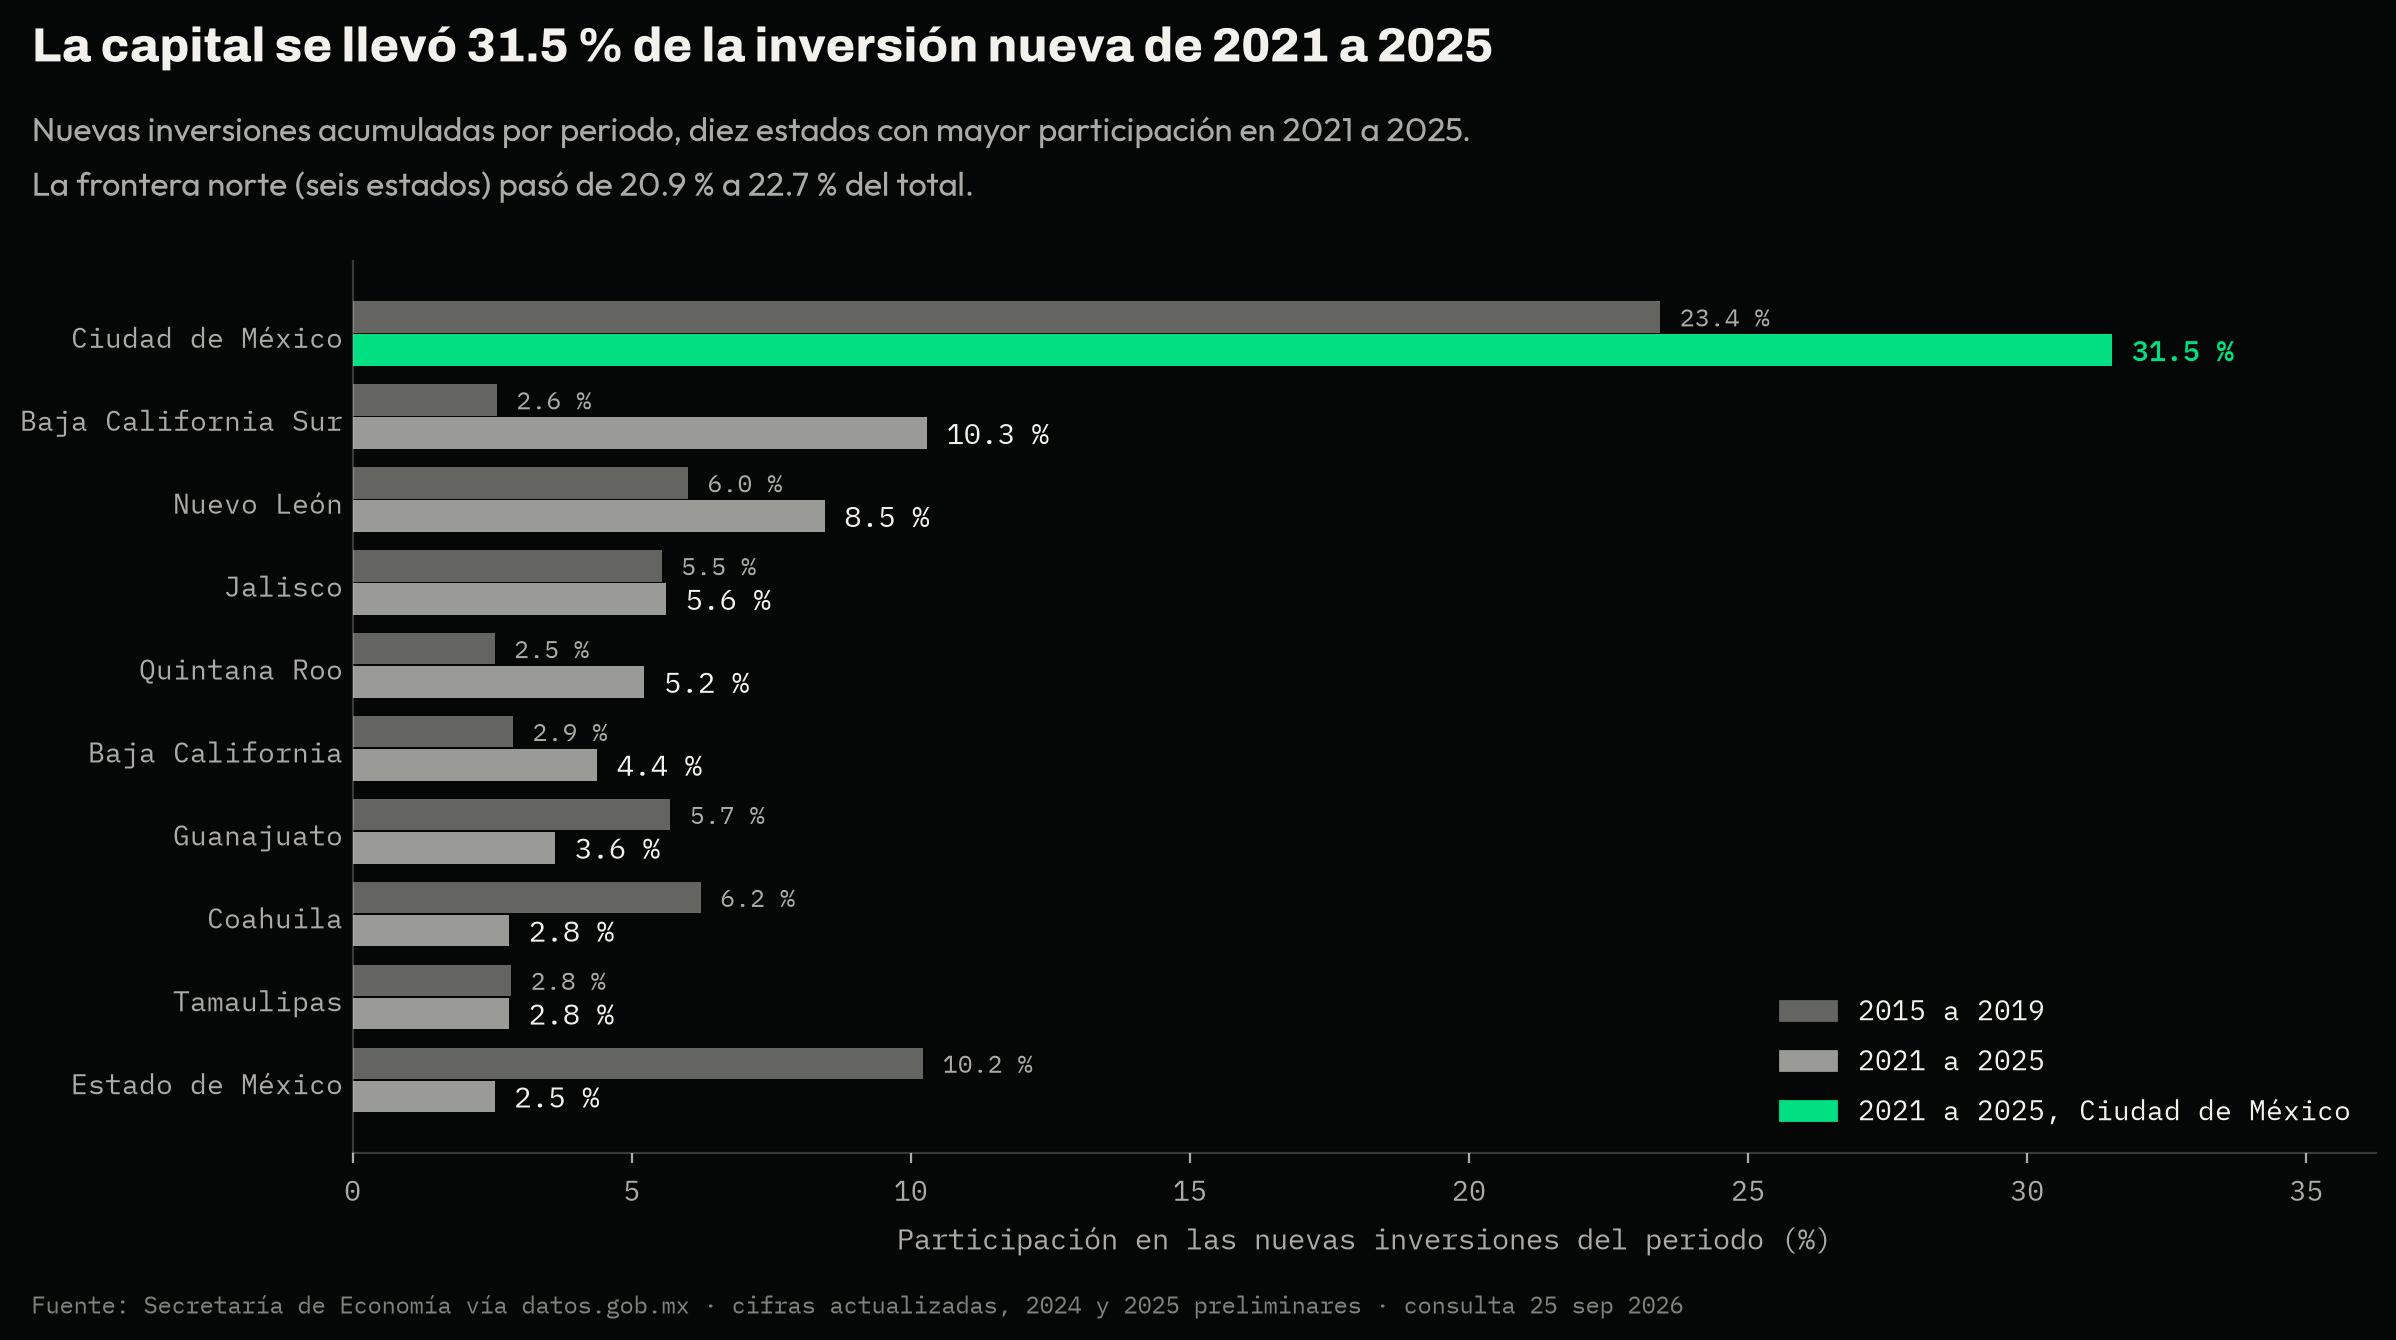

In [17]:
t10 = reparto.head(10).iloc[::-1]
es_cdmx = t10.index == "Ciudad de México"
fig, ax = plt.subplots()
y = range(len(t10))
ax.barh([i + 0.2 for i in y], t10[PREVIO], height=0.38, color=PALETA["neutro"])
ax.barh([i - 0.2 for i in y], t10[RECIENTE], height=0.38, color=[PALETA["acento"] if c else PALETA["neutro_claro"] for c in es_cdmx])
for i, (b, u, c) in enumerate(zip(t10[PREVIO], t10[RECIENTE], es_cdmx)):
    ax.text(u + 0.35, i - 0.2, f"{u:.1f} %", va="center", fontsize=10.5, fontweight=500 if c else 400,
            color=PALETA["acento"] if c else PALETA["tinta"])
    ax.text(b + 0.35, i + 0.2, f"{b:.1f} %", va="center", fontsize=9, color=PALETA["tenue"])
ax.set_yticks(list(y), t10.index)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, t10[RECIENTE].max() * 1.15)
ax.set_xlabel("Participación en las nuevas inversiones del periodo (%)")
ax.legend(handles=[Patch(color=PALETA["neutro"], label="2015 a 2019"),
                   Patch(color=PALETA["neutro_claro"], label=f"{ULTIMO - 4} a {ULTIMO}"),
                   Patch(color=PALETA["acento"], label=f"{ULTIMO - 4} a {ULTIMO}, Ciudad de México")], loc="lower right")
arriba = encabezado(
    fig, f"La capital se llevó {t10.loc['Ciudad de México', RECIENTE]:.1f} % de la inversión nueva de {ULTIMO - 4} a {ULTIMO}",
    f"Nuevas inversiones acumuladas por periodo, diez estados con mayor participación en {ULTIMO - 4} a {ULTIMO}.\n"
    f"La frontera norte (seis estados) pasó de {reparto.loc[FRONTERA, PREVIO].sum():.1f} % a "
    f"{reparto.loc[FRONTERA, RECIENTE].sum():.1f} % del total.")
pie(fig)
plt.tight_layout(rect=(0, 0.035, 1, arriba))
plt.show()

## 5. Advertencias antes de citar estas cifras

- **Asignación por estado.** Desde 2015 la SE asigna la IED de cada empresa según su presencia operativa: el destino que la empresa reporta o, si no lo tiene, un reparto que estima la propia SE; revisó 1999 a 2014 con el mismo criterio ([apéndice metodológico del informe del cuarto trimestre de 2025](https://gaceta.diputados.gob.mx/PDF/66/2026/abr/InvExt-20260414.pdf), sección 3.4; los dos criterios, en la [síntesis metodológica](https://www.gob.mx/cms/uploads/attachment/file/274849/Sintesis_metodologica_IED.pdf), sección 4). La descripción del dataset no documenta el criterio y las tablas no dicen qué parte de cada estado viene de cada método. La concentración en la capital está sobre todo en utilidades reinvertidas: 57.4 % de la reinversión del país en 2025.
- **País de origen.** Es el país donde reside el inversionista directo ([síntesis metodológica de la SE](https://www.gob.mx/cms/uploads/attachment/file/274849/Sintesis_metodologica_IED.pdf)). La inversión que entra por filiales en terceros países cuenta para esos países, así que la participación de cualquier origen, China incluida, puede diferir de la del país que controla la inversión.
- **Cifras preliminares.** La SE corrige todas las cifras en cada informe trimestral (sección 3.8 del mismo apéndice). Entre la primera cifra y la actual, el total anual de 2018 a 2025 se movió entre -2.7 % y +7.9 %, y las nuevas inversiones de 2024, +29.8 %. Todo lo anterior usa las cifras actualizadas del lote `b2026_01t`.
- **Confidenciales.** Las celdas que identificarían a una empresa no se publican; el notebook 01 cuantifica cuánto queda fuera de la suma de países.
- **Dólares corrientes.** Salvo donde se indica, las cifras están en dólares corrientes. La serie en dólares constantes usa el CPI-U de Estados Unidos, que mide precios al consumidor en ese país.
- **Primer semestre de 2026.** El datastore llega al primer trimestre de 2026. El [comunicado de la SE del 24 de agosto de 2026](https://www.gob.mx/se/prensa/mexico-registra-un-maximo-historico-de-inversion-extranjera-directa-ied-para-un-primer-semestre-34-mil-968-millones-de-dolares-en-2026) reporta 34,968 mdd en el semestre, 88.5 % de ellos reinversión de utilidades. La Ciudad de México recibió 16,862 mdd y Estados Unidos aportó 16,871 mdd: los dos equivalen a 48.2 % del total, una coincidencia del redondeo con montos distintos. Esas cifras son del comunicado; estas tablas todavía no las incluyen.